In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.13.15
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
from pathlib import Path

DATA_DIR = Path("/content/drive/MyDrive/PathoScope/data")
WORK_DIR_05 = Path("/content/pathoscope_05")

WORK_DIR_05.mkdir(parents=True, exist_ok=True)

required_files = [
    "tiles.csv",
    "tiles_img.zip",
    "tiles_norm.zip",
    "ref_stain.npz"
]

print("Data directory:", DATA_DIR)
print("\nRequired files:")

for filename in required_files:
    path = DATA_DIR / filename
    print(f"{filename}: {'FOUND' if path.exists() else 'MISSING'}")

print("\nNotebook 05 working directory:", WORK_DIR_05)

Data directory: /content/drive/MyDrive/PathoScope/data

Required files:
tiles.csv: MISSING
tiles_img.zip: MISSING
tiles_norm.zip: MISSING
ref_stain.npz: MISSING

Notebook 05 working directory: /content/pathoscope_05


In [8]:
from pathlib import Path

drive_root = Path("/content/drive/MyDrive")

matches = []

for path in drive_root.rglob("*"):
    if path.is_file() and path.name in {
        "tiles.csv",
        "tiles_img.zip",
        "tiles_norm.zip",
        "ref_stain.npz"
    }:
        matches.append(path)

print("Files found:", len(matches))

for path in matches:
    print(path)

Files found: 4
/content/drive/MyDrive/PathoScope/data/ref_stain.npz
/content/drive/MyDrive/PathoScope/data/tiles.csv
/content/drive/MyDrive/PathoScope/data/tiles_norm.zip
/content/drive/MyDrive/PathoScope/data/tiles_img.zip


In [7]:
from pathlib import Path

print("Checking Google Drive mount...")

drive_path = Path("/content/drive/MyDrive")

print("Drive exists:", drive_path.exists())
print("MyDrive exists:", drive_path.is_dir())

if drive_path.exists():
    print("\nTop-level folders in My Drive:")
    for item in sorted(drive_path.iterdir()):
        print(" -", item.name)

Checking Google Drive mount...
Drive exists: True
MyDrive exists: True

Top-level folders in My Drive:
 - 1000074960 (1).pdf
 - Class notes.gdoc
 - Colab Notebooks
 - Contact
 - DOC-20250314-WA0004..pdf
 - Getting started.pdf
 - PathoScope
 - Pradip_Palekar_cv (1).pdf
 - Pradip_Palekar_cv.pdf
 - Screenshot_2020-07-29-13-20-51-11.jpg
 - Screenshot_2021-09-25-14-11-42-10_b73d025e34d3569bf7e97abab31af632.jpg
 - Student certificate.gslides
 - Untitled document (1).gdoc
 - Untitled document.gdoc
 - Untitled folder
 - Untitled form.gform
 - Untitled presentation.gslides
 - certificate.pdf


In [6]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [9]:
from pathlib import Path

DATA_DIR = Path("/content/drive/MyDrive/PathoScope/data")
WORK_DIR_05 = Path("/content/pathoscope_05")
WORK_DIR_05.mkdir(parents=True, exist_ok=True)

required_files = [
    "tiles.csv",
    "tiles_norm.zip",
    "tiles_img.zip",
    "ref_stain.npz"
]

print("Data directory:", DATA_DIR)
print("\nRequired files:")

for filename in required_files:
    path = DATA_DIR / filename
    size_gb = path.stat().st_size / (1024 ** 3)

    print(f"{filename}: FOUND | {size_gb:.2f} GB")

print("\nNotebook 05 working directory:", WORK_DIR_05)

Data directory: /content/drive/MyDrive/PathoScope/data

Required files:
tiles.csv: FOUND | 0.00 GB
tiles_norm.zip: FOUND | 0.40 GB
tiles_img.zip: FOUND | 0.33 GB
ref_stain.npz: FOUND | 0.00 GB

Notebook 05 working directory: /content/pathoscope_05


In [10]:
import pandas as pd

tiles_df = pd.read_csv(DATA_DIR / "tiles.csv")

print("Shape:", tiles_df.shape)

print("\nColumns:")
print(tiles_df.columns.tolist())

print("\nFirst 5 rows:")
display(tiles_df.head())

print("\nData types:")
print(tiles_df.dtypes)

Shape: (12800, 13)

Columns:
['tile_id', 'image_id', 'data_provider', 'x', 'y', 'tile_size', 'tissue_fraction', 'tile_label', 'isup_grade', 'gleason_score', 'mask_available', 'image_path', 'mask_path']

First 5 rows:


,tile_id,image_id,data_provider,x,y,tile_size,tissue_fraction,tile_label,isup_grade,gleason_score,mask_available,image_path,mask_path
0,8f264374ed3fa427615c1650218e7f21_x1536_y1536,8f264374ed3fa427615c1650218e7f21,radboud,1536,1536,256,1.0,0,1,3+3,1,images/8f264374ed3fa427615c1650218e7f21_x1536_...,masks/8f264374ed3fa427615c1650218e7f21_x1536_y...
1,8f264374ed3fa427615c1650218e7f21_x1792_y4864,8f264374ed3fa427615c1650218e7f21,radboud,1792,4864,256,1.0,1,1,3+3,1,images/8f264374ed3fa427615c1650218e7f21_x1792_...,masks/8f264374ed3fa427615c1650218e7f21_x1792_y...
2,8f264374ed3fa427615c1650218e7f21_x2560_y7936,8f264374ed3fa427615c1650218e7f21,radboud,2560,7936,256,1.0,0,1,3+3,1,images/8f264374ed3fa427615c1650218e7f21_x2560_...,masks/8f264374ed3fa427615c1650218e7f21_x2560_y...
3,8f264374ed3fa427615c1650218e7f21_x2048_y8448,8f264374ed3fa427615c1650218e7f21,radboud,2048,8448,256,1.0,0,1,3+3,1,images/8f264374ed3fa427615c1650218e7f21_x2048_...,masks/8f264374ed3fa427615c1650218e7f21_x2048_y...
4,8f264374ed3fa427615c1650218e7f21_x2560_y8448,8f264374ed3fa427615c1650218e7f21,radboud,2560,8448,256,1.0,0,1,3+3,1,images/8f264374ed3fa427615c1650218e7f21_x2560_...,masks/8f264374ed3fa427615c1650218e7f21_x2560_y...



Data types:
tile_id             object
image_id            object
data_provider       object
x                    int64
y                    int64
tile_size            int64
tissue_fraction    float64
tile_label           int64
isup_grade           int64
gleason_score       object
mask_available       int64
image_path          object
mask_path           object
dtype: object


In [11]:
print("Unique slides:", tiles_df["image_id"].nunique())

tiles_per_slide = tiles_df.groupby("image_id").size()

print("\nTiles per slide:")
print(tiles_per_slide.describe())

print("\nUnique tile counts:")
print(tiles_per_slide.value_counts().sort_index())

print("\nISUP grade distribution:")
print(tiles_df.groupby("image_id")["isup_grade"].first().value_counts().sort_index())

print("\nSlides per provider:")
print(
    tiles_df.groupby("image_id")["data_provider"]
    .first()
    .value_counts()
)

print("\nChecking whether each slide has exactly one ISUP grade:")
grade_counts = tiles_df.groupby("image_id")["isup_grade"].nunique()

print("Slides with one ISUP grade:", (grade_counts == 1).sum())
print("Slides with multiple ISUP grades:", (grade_counts > 1).sum())

Unique slides: 200

Tiles per slide:
count    200.0
mean      64.0
std        0.0
min       64.0
25%       64.0
50%       64.0
75%       64.0
max       64.0
dtype: float64

Unique tile counts:
64    200
Name: count, dtype: int64

ISUP grade distribution:
isup_grade
0    55
1    50
2    25
3    23
4    24
5    23
Name: count, dtype: int64

Slides per provider:
data_provider
radboud       100
karolinska    100
Name: count, dtype: int64

Checking whether each slide has exactly one ISUP grade:
Slides with one ISUP grade: 200
Slides with multiple ISUP grades: 0


In [12]:
slide_df = (
    tiles_df
    .groupby("image_id", sort=False)
    .agg(
        isup_grade=("isup_grade", "first"),
        data_provider=("data_provider", "first"),
        n_tiles=("tile_id", "count")
    )
    .reset_index()
)

print("Slide-level table shape:", slide_df.shape)

print("\nFirst 10 slides:")
display(slide_df.head(10))

print("\nISUP distribution:")
print(
    slide_df["isup_grade"]
    .value_counts()
    .sort_index()
)

print("\nNumber of slides with 64 tiles:")
print((slide_df["n_tiles"] == 64).sum())

print("\nAny missing values:")
print(slide_df.isna().sum())

Slide-level table shape: (200, 4)

First 10 slides:


,image_id,isup_grade,data_provider,n_tiles
0,8f264374ed3fa427615c1650218e7f21,1,radboud,64
1,620261483418740878617c4e04015457,5,radboud,64
2,871f73f44e29b8f3da8048aaf387a673,1,karolinska,64
3,2cd038d5c85feb0a8da44407e4fb6a5a,2,radboud,64
4,abb213da3051a8ef6e482b3882ad9d4b,0,karolinska,64
5,3f5ace05ae2e2cee322fdee09da53f0a,2,radboud,64
6,932c710132acaf350cbc949b53417207,0,karolinska,64
7,921e586c2b5c9ac5b164f2229f7ea9f6,2,radboud,64
8,49a2ed9b6af2a48a788b9dd6066bdb0a,4,radboud,64
9,71abdfb52804bed1259c90f7b414e178,0,radboud,64



ISUP distribution:
isup_grade
0    55
1    50
2    25
3    23
4    24
5    23
Name: count, dtype: int64

Number of slides with 64 tiles:
200

Any missing values:
image_id         0
isup_grade       0
data_provider    0
n_tiles          0
dtype: int64


In [13]:
from sklearn.model_selection import train_test_split

SEED = 42

train_slides, temp_slides = train_test_split(
    slide_df,
    test_size=0.30,
    stratify=slide_df["isup_grade"],
    random_state=SEED
)

val_slides, test_slides = train_test_split(
    temp_slides,
    test_size=0.50,
    stratify=temp_slides["isup_grade"],
    random_state=SEED
)

train_slides = train_slides.reset_index(drop=True)
val_slides = val_slides.reset_index(drop=True)
test_slides = test_slides.reset_index(drop=True)

print("Train slides:", len(train_slides))
print("Validation slides:", len(val_slides))
print("Test slides:", len(test_slides))

print("\nTrain ISUP distribution:")
print(train_slides["isup_grade"].value_counts().sort_index())

print("\nValidation ISUP distribution:")
print(val_slides["isup_grade"].value_counts().sort_index())

print("\nTest ISUP distribution:")
print(test_slides["isup_grade"].value_counts().sort_index())

print("\nSlide overlap checks:")
print("Train ∩ Validation:", len(set(train_slides.image_id) & set(val_slides.image_id)))
print("Train ∩ Test:", len(set(train_slides.image_id) & set(test_slides.image_id)))
print("Validation ∩ Test:", len(set(val_slides.image_id) & set(test_slides.image_id)))

Train slides: 140
Validation slides: 30
Test slides: 30

Train ISUP distribution:
isup_grade
0    38
1    35
2    18
3    16
4    17
5    16
Name: count, dtype: int64

Validation ISUP distribution:
isup_grade
0    9
1    8
2    3
3    3
4    3
5    4
Name: count, dtype: int64

Test ISUP distribution:
isup_grade
0    8
1    7
2    4
3    4
4    4
5    3
Name: count, dtype: int64

Slide overlap checks:
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [14]:
import zipfile

NORM_DIR = WORK_DIR_05 / "tiles_norm"

if not NORM_DIR.exists():
    NORM_DIR.mkdir(parents=True, exist_ok=True)

    print("Extracting normalized tiles...")

    with zipfile.ZipFile(DATA_DIR / "tiles_norm.zip", "r") as zip_ref:
        zip_ref.extractall(NORM_DIR)

    print("Extraction complete.")
else:
    print("Normalized tile directory already exists. Skipping extraction.")

norm_files = list(NORM_DIR.rglob("*.jpg"))

print("\nNormalized JPEG files found:", len(norm_files))

print("\nExample files:")
for path in norm_files[:5]:
    print(path)

Extracting normalized tiles...
Extraction complete.

Normalized JPEG files found: 12800

Example files:
/content/pathoscope_05/tiles_norm/7a40364bb1370598575caac647f1635f_x5888_y8704.jpg
/content/pathoscope_05/tiles_norm/8f264374ed3fa427615c1650218e7f21_x2816_y5888.jpg
/content/pathoscope_05/tiles_norm/33f343b9a016f58f2e78d1b2109ffab9_x12800_y5376.jpg
/content/pathoscope_05/tiles_norm/16cc34b16c0b30e43e8c33f572440ae6_x768_y7168.jpg
/content/pathoscope_05/tiles_norm/20b65b9fdf04f2d2d80f515bc939ee7a_x7680_y22784.jpg


In [15]:
def normalized_tile_path(row):
    return NORM_DIR / Path(row["image_path"]).name

tiles_df["norm_path"] = tiles_df.apply(normalized_tile_path, axis=1)

exists_mask = tiles_df["norm_path"].map(Path.exists)

print("Total tiles:", len(tiles_df))
print("Matching normalized files:", exists_mask.sum())
print("Missing normalized files:", (~exists_mask).sum())

print("\nExample mappings:")
display(
    tiles_df[
        ["tile_id", "image_id", "image_path", "norm_path"]
    ].head(5)
)

if (~exists_mask).sum() == 0:
    print("\n✓ All tile paths successfully mapped.")
else:
    print("\n⚠ Missing files detected.")

Total tiles: 12800
Matching normalized files: 12800
Missing normalized files: 0

Example mappings:


,tile_id,image_id,image_path,norm_path
0,8f264374ed3fa427615c1650218e7f21_x1536_y1536,8f264374ed3fa427615c1650218e7f21,images/8f264374ed3fa427615c1650218e7f21_x1536_...,/content/pathoscope_05/tiles_norm/8f264374ed3f...
1,8f264374ed3fa427615c1650218e7f21_x1792_y4864,8f264374ed3fa427615c1650218e7f21,images/8f264374ed3fa427615c1650218e7f21_x1792_...,/content/pathoscope_05/tiles_norm/8f264374ed3f...
2,8f264374ed3fa427615c1650218e7f21_x2560_y7936,8f264374ed3fa427615c1650218e7f21,images/8f264374ed3fa427615c1650218e7f21_x2560_...,/content/pathoscope_05/tiles_norm/8f264374ed3f...
3,8f264374ed3fa427615c1650218e7f21_x2048_y8448,8f264374ed3fa427615c1650218e7f21,images/8f264374ed3fa427615c1650218e7f21_x2048_...,/content/pathoscope_05/tiles_norm/8f264374ed3f...
4,8f264374ed3fa427615c1650218e7f21_x2560_y8448,8f264374ed3fa427615c1650218e7f21,images/8f264374ed3fa427615c1650218e7f21_x2560_...,/content/pathoscope_05/tiles_norm/8f264374ed3f...



✓ All tile paths successfully mapped.


In [16]:
slide_tile_groups = {}

for image_id, group in tiles_df.groupby("image_id", sort=False):
    slide_tile_groups[image_id] = group.sort_values("tile_id").reset_index(drop=True)

print("Number of slide bags:", len(slide_tile_groups))

bag_sizes = [len(group) for group in slide_tile_groups.values()]

print("\nBag size statistics:")
print(pd.Series(bag_sizes).describe())

print("\nUnique bag sizes:")
print(pd.Series(bag_sizes).value_counts().sort_index())

example_slide = next(iter(slide_tile_groups))

print("\nExample slide:", example_slide)
print("Number of tiles:", len(slide_tile_groups[example_slide]))

display(
    slide_tile_groups[example_slide][
        ["tile_id", "image_id", "norm_path", "isup_grade"]
    ].head(10)
)

Number of slide bags: 200

Bag size statistics:
count    200.0
mean      64.0
std        0.0
min       64.0
25%       64.0
50%       64.0
75%       64.0
max       64.0
dtype: float64

Unique bag sizes:
64    200
Name: count, dtype: int64

Example slide: 8f264374ed3fa427615c1650218e7f21
Number of tiles: 64


,tile_id,image_id,norm_path,isup_grade
0,8f264374ed3fa427615c1650218e7f21_x1024_y16384,8f264374ed3fa427615c1650218e7f21,/content/pathoscope_05/tiles_norm/8f264374ed3f...,1
1,8f264374ed3fa427615c1650218e7f21_x1024_y16640,8f264374ed3fa427615c1650218e7f21,/content/pathoscope_05/tiles_norm/8f264374ed3f...,1
2,8f264374ed3fa427615c1650218e7f21_x1024_y16896,8f264374ed3fa427615c1650218e7f21,/content/pathoscope_05/tiles_norm/8f264374ed3f...,1
3,8f264374ed3fa427615c1650218e7f21_x1024_y17152,8f264374ed3fa427615c1650218e7f21,/content/pathoscope_05/tiles_norm/8f264374ed3f...,1
4,8f264374ed3fa427615c1650218e7f21_x1024_y18176,8f264374ed3fa427615c1650218e7f21,/content/pathoscope_05/tiles_norm/8f264374ed3f...,1
5,8f264374ed3fa427615c1650218e7f21_x1024_y18432,8f264374ed3fa427615c1650218e7f21,/content/pathoscope_05/tiles_norm/8f264374ed3f...,1
6,8f264374ed3fa427615c1650218e7f21_x1024_y18688,8f264374ed3fa427615c1650218e7f21,/content/pathoscope_05/tiles_norm/8f264374ed3f...,1
7,8f264374ed3fa427615c1650218e7f21_x1024_y18944,8f264374ed3fa427615c1650218e7f21,/content/pathoscope_05/tiles_norm/8f264374ed3f...,1
8,8f264374ed3fa427615c1650218e7f21_x1024_y19200,8f264374ed3fa427615c1650218e7f21,/content/pathoscope_05/tiles_norm/8f264374ed3f...,1
9,8f264374ed3fa427615c1650218e7f21_x1024_y19456,8f264374ed3fa427615c1650218e7f21,/content/pathoscope_05/tiles_norm/8f264374ed3f...,1


In [17]:
from PIL import Image
import numpy as np

example_paths = tiles_df["norm_path"].iloc[:5].tolist()

print("Testing image loading...\n")

for i, path in enumerate(example_paths, start=1):
    image = Image.open(path)
    array = np.array(image)

    print(f"Image {i}")
    print("  Path:", path.name)
    print("  Size:", image.size)
    print("  Mode:", image.mode)
    print("  Shape:", array.shape)
    print("  Dtype:", array.dtype)
    print("  Min:", array.min())
    print("  Max:", array.max())
    print()

Testing image loading...

Image 1
  Path: 8f264374ed3fa427615c1650218e7f21_x1536_y1536.jpg
  Size: (256, 256)
  Mode: RGB
  Shape: (256, 256, 3)
  Dtype: uint8
  Min: 0
  Max: 255

Image 2
  Path: 8f264374ed3fa427615c1650218e7f21_x1792_y4864.jpg
  Size: (256, 256)
  Mode: RGB
  Shape: (256, 256, 3)
  Dtype: uint8
  Min: 1
  Max: 255

Image 3
  Path: 8f264374ed3fa427615c1650218e7f21_x2560_y7936.jpg
  Size: (256, 256)
  Mode: RGB
  Shape: (256, 256, 3)
  Dtype: uint8
  Min: 0
  Max: 255

Image 4
  Path: 8f264374ed3fa427615c1650218e7f21_x2048_y8448.jpg
  Size: (256, 256)
  Mode: RGB
  Shape: (256, 256, 3)
  Dtype: uint8
  Min: 21
  Max: 255

Image 5
  Path: 8f264374ed3fa427615c1650218e7f21_x2560_y8448.jpg
  Size: (256, 256)
  Mode: RGB
  Shape: (256, 256, 3)
  Dtype: uint8
  Min: 6
  Max: 255



In [18]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

weights = models.EfficientNet_B0_Weights.DEFAULT

encoder = models.efficientnet_b0(weights=weights)

# Remove the final classification layer.
encoder.classifier = nn.Identity()

encoder = encoder.to(device)
encoder.eval()

print("Encoder: EfficientNet-B0")
print("Output feature dimension: 1280")
print("Parameters:", sum(p.numel() for p in encoder.parameters()))

Device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 147MB/s]


Encoder: EfficientNet-B0
Output feature dimension: 1280
Parameters: 4007548


In [19]:
from PIL import Image
import torch
from torchvision import transforms

weights = models.EfficientNet_B0_Weights.DEFAULT
preprocess = weights.transforms()

sample_path = tiles_df["norm_path"].iloc[0]

image = Image.open(sample_path).convert("RGB")
input_tensor = preprocess(image).unsqueeze(0).to(device)

print("Input tensor shape:", input_tensor.shape)
print("Input dtype:", input_tensor.dtype)
print("Input device:", input_tensor.device)

with torch.no_grad():
    feature = encoder(input_tensor)

print("\nFeature shape:", feature.shape)
print("Feature dtype:", feature.dtype)
print("Feature device:", feature.device)
print("Feature min:", feature.min().item())
print("Feature max:", feature.max().item())

Input tensor shape: torch.Size([1, 3, 224, 224])
Input dtype: torch.float32
Input device: cuda:0

Feature shape: torch.Size([1, 1280])
Feature dtype: torch.float32
Feature device: cuda:0
Feature min: -0.25482454895973206
Feature max: 2.4097914695739746


In [20]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm.auto import tqdm

class TileFeatureDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["norm_path"]).convert("RGB")
        image = self.transform(image)

        return image, idx


feature_dataset = TileFeatureDataset(
    tiles_df,
    preprocess
)

feature_loader = DataLoader(
    feature_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

all_features = torch.zeros(
    len(tiles_df),
    1280,
    dtype=torch.float32
)

encoder.eval()

print("Extracting features...")
print("Total tiles:", len(feature_dataset))
print("Batch size:", 64)

with torch.no_grad():
    for images, indices in tqdm(feature_loader):
        images = images.to(device, non_blocking=True)

        features = encoder(images)

        all_features[indices] = features.cpu()

print("\nFeature extraction complete.")
print("Feature matrix shape:", all_features.shape)
print("Feature dtype:", all_features.dtype)
print("Feature min:", all_features.min().item())
print("Feature max:", all_features.max().item())

Extracting features...
Total tiles: 12800
Batch size: 64


  0%|          | 0/200 [00:00<?, ?it/s]


Feature extraction complete.
Feature matrix shape: torch.Size([12800, 1280])
Feature dtype: torch.float32
Feature min: -0.2751368284225464
Feature max: 6.10412073135376


In [21]:
FEATURES_PATH = WORK_DIR_05 / "tile_features.pt"

torch.save(all_features, FEATURES_PATH)

print("Features saved to:")
print(FEATURES_PATH)

print("\nFile size:")
print(f"{FEATURES_PATH.stat().st_size / (1024 ** 2):.2f} MB")

print("\nSaved tensor shape:")
print(torch.load(FEATURES_PATH, map_location="cpu").shape)

Features saved to:
/content/pathoscope_05/tile_features.pt

File size:
62.50 MB

Saved tensor shape:
torch.Size([12800, 1280])


In [22]:
slide_features = []
slide_labels = []
slide_ids = []

for image_id, group in tiles_df.groupby("image_id", sort=False):
    group = group.sort_values("tile_id")

    tile_indices = group.index.to_numpy()

    features = all_features[tile_indices]

    slide_features.append(features)
    slide_labels.append(int(group["isup_grade"].iloc[0]))
    slide_ids.append(image_id)

slide_features = torch.stack(slide_features)
slide_labels = torch.tensor(slide_labels, dtype=torch.long)

print("Slide feature tensor shape:", slide_features.shape)
print("Slide label tensor shape:", slide_labels.shape)

print("\nExpected:")
print("Slides:", 200)
print("Tiles per slide:", 64)
print("Features per tile:", 1280)

print("\nFirst slide:")
print("Slide ID:", slide_ids[0])
print("ISUP grade:", slide_labels[0].item())
print("Feature shape:", slide_features[0].shape)

Slide feature tensor shape: torch.Size([200, 64, 1280])
Slide label tensor shape: torch.Size([200])

Expected:
Slides: 200
Tiles per slide: 64
Features per tile: 1280

First slide:
Slide ID: 8f264374ed3fa427615c1650218e7f21
ISUP grade: 1
Feature shape: torch.Size([64, 1280])


In [23]:
slide_id_to_index = {
    slide_id: idx
    for idx, slide_id in enumerate(slide_ids)
}

train_indices = [
    slide_id_to_index[slide_id]
    for slide_id in train_slides["image_id"]
]

val_indices = [
    slide_id_to_index[slide_id]
    for slide_id in val_slides["image_id"]
]

test_indices = [
    slide_id_to_index[slide_id]
    for slide_id in test_slides["image_id"]
]

train_features = slide_features[train_indices]
train_labels = slide_labels[train_indices]

val_features = slide_features[val_indices]
val_labels = slide_labels[val_indices]

test_features = slide_features[test_indices]
test_labels = slide_labels[test_indices]

print("Train features:", train_features.shape)
print("Train labels:", train_labels.shape)

print("Validation features:", val_features.shape)
print("Validation labels:", val_labels.shape)

print("Test features:", test_features.shape)
print("Test labels:", test_labels.shape)

print("\nTrain label distribution:")
print(torch.bincount(train_labels, minlength=6))

print("\nValidation label distribution:")
print(torch.bincount(val_labels, minlength=6))

print("\nTest label distribution:")
print(torch.bincount(test_labels, minlength=6))

Train features: torch.Size([140, 64, 1280])
Train labels: torch.Size([140])
Validation features: torch.Size([30, 64, 1280])
Validation labels: torch.Size([30])
Test features: torch.Size([30, 64, 1280])
Test labels: torch.Size([30])

Train label distribution:
tensor([38, 35, 18, 16, 17, 16])

Validation label distribution:
tensor([9, 8, 3, 3, 3, 4])

Test label distribution:
tensor([8, 7, 4, 4, 4, 3])


In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class AttentionMIL(nn.Module):
    def __init__(
        self,
        input_dim=1280,
        hidden_dim=256,
        num_classes=6
    ):
        super().__init__()

        self.feature_projection = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.25)
        )

        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, num_classes)
        )

    def forward(self, x, return_attention=False):
        # x: [batch, tiles, features]

        h = self.feature_projection(x)
        # h: [batch, tiles, hidden_dim]

        attention_logits = self.attention(h)
        # [batch, tiles, 1]

        attention_weights = F.softmax(
            attention_logits,
            dim=1
        )

        slide_representation = torch.sum(
            attention_weights * h,
            dim=1
        )
        # [batch, hidden_dim]

        logits = self.classifier(slide_representation)

        if return_attention:
            return logits, attention_weights.squeeze(-1)

        return logits


mil_model = AttentionMIL(
    input_dim=1280,
    hidden_dim=256,
    num_classes=6
).to(device)

print(mil_model)

print("\nTotal parameters:")
print(sum(p.numel() for p in mil_model.parameters()))

print("\nTrainable parameters:")
print(
    sum(
        p.numel()
        for p in mil_model.parameters()
        if p.requires_grad
    )
)

AttentionMIL(
  (feature_projection): Sequential(
    (0): Linear(in_features=1280, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
  )
  (attention): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=128, out_features=6, bias=True)
  )
)

Total parameters:
394631

Trainable parameters:
394631


In [25]:
mil_model.eval()

sample_bag = train_features[0].unsqueeze(0).to(device)

with torch.no_grad():
    sample_logits, sample_attention = mil_model(
        sample_bag,
        return_attention=True
    )

print("Input shape:", sample_bag.shape)
print("Logits shape:", sample_logits.shape)
print("Attention shape:", sample_attention.shape)

print("\nLogits:")
print(sample_logits)

print("\nAttention weights:")
print(sample_attention)

print("\nAttention sum:")
print(sample_attention.sum(dim=1))

print("\nPredicted ISUP:")
print(sample_logits.argmax(dim=1).item())

print("True ISUP:")
print(train_labels[0].item())

Input shape: torch.Size([1, 64, 1280])
Logits shape: torch.Size([1, 6])
Attention shape: torch.Size([1, 64])

Logits:
tensor([[ 0.0184,  0.0374,  0.0286, -0.1132,  0.0517,  0.0989]],
       device='cuda:0')

Attention weights:
tensor([[0.0154, 0.0158, 0.0156, 0.0158, 0.0154, 0.0155, 0.0159, 0.0173, 0.0156,
         0.0173, 0.0165, 0.0154, 0.0154, 0.0155, 0.0156, 0.0154, 0.0163, 0.0151,
         0.0163, 0.0164, 0.0157, 0.0160, 0.0162, 0.0162, 0.0151, 0.0153, 0.0156,
         0.0174, 0.0159, 0.0173, 0.0150, 0.0156, 0.0157, 0.0158, 0.0157, 0.0148,
         0.0148, 0.0163, 0.0164, 0.0165, 0.0158, 0.0152, 0.0151, 0.0152, 0.0149,
         0.0153, 0.0152, 0.0154, 0.0154, 0.0153, 0.0161, 0.0145, 0.0148, 0.0153,
         0.0154, 0.0145, 0.0148, 0.0148, 0.0152, 0.0159, 0.0147, 0.0152, 0.0156,
         0.0155]], device='cuda:0')

Attention sum:
tensor([1.], device='cuda:0')

Predicted ISUP:
5
True ISUP:
0


In [26]:
from sklearn.metrics import cohen_kappa_score
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 16
EPOCHS = 30
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5

train_dataset = TensorDataset(
    train_features,
    train_labels
)

val_dataset = TensorDataset(
    val_features,
    val_labels
)

test_dataset = TensorDataset(
    test_features,
    test_labels
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    mil_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("Training configuration:")
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)

print("\nLoss:", criterion)

print("\nOptimizer:")
print(optimizer)

print("\nQWK test:")
example_true = [0, 1, 2, 3, 4, 5]
example_pred = [0, 1, 2, 3, 4, 5]

print(
    cohen_kappa_score(
        example_true,
        example_pred,
        weights="quadratic"
    )
)

Training configuration:
Batch size: 16
Epochs: 30
Learning rate: 0.0001
Weight decay: 1e-05

Loss: CrossEntropyLoss()

Optimizer:
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 1e-05
)

QWK test:
1.0


In [27]:
import copy
import time

BEST_QWK = -1.0
BEST_EPOCH = 0
BEST_STATE = None

history = []

print("Starting Attention-MIL training...\n")

for epoch in range(1, EPOCHS + 1):

    start_time = time.time()

    # Training
    mil_model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for features, labels in train_loader:

        features = features.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = mil_model(features)

        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * labels.size(0)

        predictions = logits.argmax(dim=1)

        train_correct += (
            predictions == labels
        ).sum().item()

        train_total += labels.size(0)

    train_loss /= train_total
    train_accuracy = train_correct / train_total

    # Validation
    mil_model.eval()

    val_loss = 0.0
    val_predictions = []
    val_targets = []

    with torch.no_grad():

        for features, labels in val_loader:

            features = features.to(device)
            labels = labels.to(device)

            logits = mil_model(features)

            loss = criterion(logits, labels)

            val_loss += loss.item() * labels.size(0)

            predictions = logits.argmax(dim=1)

            val_predictions.extend(
                predictions.cpu().numpy()
            )

            val_targets.extend(
                labels.cpu().numpy()
            )

    val_loss /= len(val_dataset)

    val_qwk = cohen_kappa_score(
        val_targets,
        val_predictions,
        weights="quadratic"
    )

    val_accuracy = np.mean(
        np.array(val_predictions) ==
        np.array(val_targets)
    )

    epoch_time = time.time() - start_time

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
        "val_qwk": val_qwk,
        "time_seconds": epoch_time
    })

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val QWK: {val_qwk:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

    if val_qwk > BEST_QWK:

        BEST_QWK = val_qwk
        BEST_EPOCH = epoch
        BEST_STATE = copy.deepcopy(
            mil_model.state_dict()
        )

        print(
            f"  ✓ New best model "
            f"(Validation QWK = {BEST_QWK:.4f})"
        )

print("\nTraining complete.")

print("Best epoch:", BEST_EPOCH)
print("Best validation QWK:", BEST_QWK)

Starting Attention-MIL training...

Epoch 01/30 | Train Loss: 1.7849 | Train Acc: 0.1786 | Val Loss: 1.7526 | Val Acc: 0.2667 | Val QWK: 0.0107 | Time: 0.5s
  ✓ New best model (Validation QWK = 0.0107)
Epoch 02/30 | Train Loss: 1.7548 | Train Acc: 0.2500 | Val Loss: 1.7234 | Val Acc: 0.2667 | Val QWK: 0.0000 | Time: 0.1s
Epoch 03/30 | Train Loss: 1.7267 | Train Acc: 0.2714 | Val Loss: 1.6989 | Val Acc: 0.2667 | Val QWK: 0.0000 | Time: 0.1s
Epoch 04/30 | Train Loss: 1.7099 | Train Acc: 0.3000 | Val Loss: 1.6738 | Val Acc: 0.2667 | Val QWK: -0.0732 | Time: 0.1s
Epoch 05/30 | Train Loss: 1.6969 | Train Acc: 0.2643 | Val Loss: 1.6480 | Val Acc: 0.3000 | Val QWK: -0.0636 | Time: 0.1s
Epoch 06/30 | Train Loss: 1.6675 | Train Acc: 0.3214 | Val Loss: 1.6277 | Val Acc: 0.3000 | Val QWK: -0.0531 | Time: 0.1s
Epoch 07/30 | Train Loss: 1.6568 | Train Acc: 0.3143 | Val Loss: 1.6171 | Val Acc: 0.2667 | Val QWK: -0.0923 | Time: 0.1s
Epoch 08/30 | Train Loss: 1.6419 | Train Acc: 0.3071 | Val Loss: 1.6

In [28]:
# Restore the model with the best validation QWK
mil_model.load_state_dict(BEST_STATE)

mil_model.eval()

MIL_MODEL_PATH = WORK_DIR_05 / "mil.pth"

torch.save(
    {
        "model_state_dict": mil_model.state_dict(),
        "input_dim": 1280,
        "hidden_dim": 256,
        "num_classes": 6,
        "best_epoch": BEST_EPOCH,
        "best_val_qwk": BEST_QWK
    },
    MIL_MODEL_PATH
)

print("Best model restored.")
print("Best epoch:", BEST_EPOCH)
print("Best validation QWK:", BEST_QWK)

print("\nModel saved to:")
print(MIL_MODEL_PATH)

print("\nFile size:")
print(f"{MIL_MODEL_PATH.stat().st_size / (1024 ** 2):.2f} MB")

Best model restored.
Best epoch: 21
Best validation QWK: 0.5125628140703518

Model saved to:
/content/pathoscope_05/mil.pth

File size:
1.51 MB


In [30]:
class MeanPoolMLP(nn.Module):
    def __init__(self, input_dim=1280, hidden_dim=256, num_classes=6):
        super().__init__()

        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x shape: [batch, 64 tiles, 1280 features]
        slide_representation = x.mean(dim=1)

        # slide_representation shape: [batch, 1280]
        logits = self.classifier(slide_representation)

        return logits


mean_model = MeanPoolMLP(
    input_dim=1280,
    hidden_dim=256,
    num_classes=6
).to(device)

print("Model:", mean_model.__class__.__name__)
print("Parameters:", sum(p.numel() for p in mean_model.parameters()))
print("Device:", device)

Model: MeanPoolMLP
Parameters: 361606
Device: cuda


In [31]:
# Test one slide
sample_x = train_features[:1].to(device)

with torch.no_grad():
    sample_logits = mean_model(sample_x)

print("Input shape:", sample_x.shape)
print("Output shape:", sample_logits.shape)
print("Logits:", sample_logits)
print("Predicted ISUP:", sample_logits.argmax(dim=1).item())
print("True ISUP:", train_labels[0].item())

Input shape: torch.Size([1, 64, 1280])
Output shape: torch.Size([1, 6])
Logits: tensor([[-0.0462,  0.0052, -0.0489, -0.0204,  0.0915,  0.0911]],
       device='cuda:0')
Predicted ISUP: 4
True ISUP: 0


In [32]:
mean_train_loader = DataLoader(
    TensorDataset(train_features, train_labels),
    batch_size=16,
    shuffle=True
)

mean_val_loader = DataLoader(
    TensorDataset(val_features, val_labels),
    batch_size=16,
    shuffle=False
)

criterion_mean = nn.CrossEntropyLoss()

optimizer_mean = torch.optim.Adam(
    mean_model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

mean_history = []
best_mean_qwk = -float("inf")
best_mean_epoch = 0
best_mean_state = None

for epoch in range(1, 31):
    mean_model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for x_batch, y_batch in mean_train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer_mean.zero_grad()

        logits = mean_model(x_batch)
        loss = criterion_mean(logits, y_batch)

        loss.backward()
        optimizer_mean.step()

        train_loss += loss.item() * y_batch.size(0)
        train_correct += (logits.argmax(dim=1) == y_batch).sum().item()
        train_total += y_batch.size(0)

    mean_model.eval()

    val_loss = 0.0
    val_preds = []
    val_true = []

    with torch.no_grad():
        for x_batch, y_batch in mean_val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = mean_model(x_batch)
            loss = criterion_mean(logits, y_batch)

            val_loss += loss.item() * y_batch.size(0)

            val_preds.extend(logits.argmax(dim=1).cpu().numpy())
            val_true.extend(y_batch.cpu().numpy())

    train_loss /= train_total
    train_acc = train_correct / train_total
    val_loss /= len(val_true)
    val_acc = np.mean(np.array(val_preds) == np.array(val_true))

    val_qwk = cohen_kappa_score(
        val_true,
        val_preds,
        weights="quadratic"
    )

    mean_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_qwk": val_qwk
    })

    if val_qwk > best_mean_qwk:
        best_mean_qwk = val_qwk
        best_mean_epoch = epoch
        best_mean_state = {
            k: v.detach().cpu().clone()
            for k, v in mean_model.state_dict().items()
        }

    print(
        f"Epoch {epoch:02d}/30 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val QWK: {val_qwk:.4f}"
    )

print("\nBest Mean Pooling result")
print("Best epoch:", best_mean_epoch)
print("Best validation QWK:", best_mean_qwk)

Epoch 01/30 | Train Loss: 1.7928 | Train Acc: 0.1500 | Val Loss: 1.7723 | Val Acc: 0.3333 | Val QWK: 0.6256
Epoch 02/30 | Train Loss: 1.7696 | Train Acc: 0.2571 | Val Loss: 1.7441 | Val Acc: 0.2667 | Val QWK: 0.0000
Epoch 03/30 | Train Loss: 1.7493 | Train Acc: 0.2786 | Val Loss: 1.7204 | Val Acc: 0.2667 | Val QWK: -0.0894
Epoch 04/30 | Train Loss: 1.7312 | Train Acc: 0.3071 | Val Loss: 1.6954 | Val Acc: 0.2667 | Val QWK: -0.0894
Epoch 05/30 | Train Loss: 1.7131 | Train Acc: 0.3143 | Val Loss: 1.6745 | Val Acc: 0.3333 | Val QWK: -0.0342
Epoch 06/30 | Train Loss: 1.6877 | Train Acc: 0.2714 | Val Loss: 1.6544 | Val Acc: 0.3333 | Val QWK: -0.0360
Epoch 07/30 | Train Loss: 1.6802 | Train Acc: 0.3357 | Val Loss: 1.6370 | Val Acc: 0.2667 | Val QWK: -0.0408
Epoch 08/30 | Train Loss: 1.6703 | Train Acc: 0.3786 | Val Loss: 1.6228 | Val Acc: 0.2667 | Val QWK: -0.0408
Epoch 09/30 | Train Loss: 1.6502 | Train Acc: 0.2929 | Val Loss: 1.6145 | Val Acc: 0.3000 | Val QWK: -0.0531
Epoch 10/30 | Train L

In [33]:
# Restore the best Mean Pooling checkpoint
mean_model.load_state_dict(best_mean_state)
mean_model = mean_model.to(device)
mean_model.eval()

test_loader = DataLoader(
    TensorDataset(test_features, test_labels),
    batch_size=16,
    shuffle=False
)

test_preds_mean = []
test_true_mean = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)

        logits = mean_model(x_batch)
        preds = logits.argmax(dim=1)

        test_preds_mean.extend(preds.cpu().numpy())
        test_true_mean.extend(y_batch.numpy())

test_acc_mean = np.mean(
    np.array(test_preds_mean) == np.array(test_true_mean)
)

test_qwk_mean = cohen_kappa_score(
    test_true_mean,
    test_preds_mean,
    weights="quadratic"
)

print("Mean Pooling + MLP")
print("Best validation epoch:", best_mean_epoch)
print("Best validation QWK:", round(best_mean_qwk, 4))
print("Test Accuracy:", round(test_acc_mean, 4))
print("Test QWK:", round(test_qwk_mean, 4))
print("\nTrue ISUP:", test_true_mean)
print("Predicted ISUP:", test_preds_mean)

Mean Pooling + MLP
Best validation epoch: 1
Best validation QWK: 0.6256
Test Accuracy: 0.1667
Test QWK: 0.0942

True ISUP: [np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(4), np.int64(4), np.int64(1), np.int64(0), np.int64(2), np.int64(0), np.int64(3), np.int64(2), np.int64(3), np.int64(1), np.int64(4), np.int64(5), np.int64(2), np.int64(1), np.int64(5), np.int64(3), np.int64(5), np.int64(4), np.int64(3), np.int64(1), np.int64(0), np.int64(1), np.int64(2)]
Predicted ISUP: [np.int64(1), np.int64(1), np.int64(5), np.int64(4), np.int64(1), np.int64(5), np.int64(4), np.int64(5), np.int64(1), np.int64(1), np.int64(1), np.int64(5), np.int64(4), np.int64(1), np.int64(5), np.int64(1), np.int64(5), np.int64(1), np.int64(5), np.int64(5), np.int64(4), np.int64(4), np.int64(1), np.int64(4), np.int64(4), np.int64(4), np.int64(1), np.int64(1), np.int64(4), np.int64(1)]


In [34]:
class MaxPoolMLP(nn.Module):
    def __init__(self, input_dim=1280, hidden_dim=256, num_classes=6):
        super().__init__()

        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # Select the strongest activation from each feature across the 64 tiles
        slide_representation = x.max(dim=1).values

        logits = self.classifier(slide_representation)

        return logits


max_model = MaxPoolMLP(
    input_dim=1280,
    hidden_dim=256,
    num_classes=6
).to(device)

print("Model:", max_model.__class__.__name__)
print("Parameters:", sum(p.numel() for p in max_model.parameters()))
print("Device:", device)

Model: MaxPoolMLP
Parameters: 361606
Device: cuda


In [35]:
sample_x = train_features[:1].to(device)

with torch.no_grad():
    sample_logits = max_model(sample_x)

print("Input shape:", sample_x.shape)
print("Output shape:", sample_logits.shape)
print("Logits:", sample_logits)
print("Predicted ISUP:", sample_logits.argmax(dim=1).item())
print("True ISUP:", train_labels[0].item())

Input shape: torch.Size([1, 64, 1280])
Output shape: torch.Size([1, 6])
Logits: tensor([[-0.0476,  0.0534, -0.0710,  0.1132,  0.1115, -0.0691]],
       device='cuda:0')
Predicted ISUP: 3
True ISUP: 0


In [36]:
max_train_loader = DataLoader(
    TensorDataset(train_features, train_labels),
    batch_size=16,
    shuffle=True
)

max_val_loader = DataLoader(
    TensorDataset(val_features, val_labels),
    batch_size=16,
    shuffle=False
)

criterion_max = nn.CrossEntropyLoss()

optimizer_max = torch.optim.Adam(
    max_model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

max_history = []
best_max_qwk = -float("inf")
best_max_epoch = 0
best_max_state = None

for epoch in range(1, 31):
    max_model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for x_batch, y_batch in max_train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer_max.zero_grad()

        logits = max_model(x_batch)
        loss = criterion_max(logits, y_batch)

        loss.backward()
        optimizer_max.step()

        train_loss += loss.item() * y_batch.size(0)
        train_correct += (logits.argmax(dim=1) == y_batch).sum().item()
        train_total += y_batch.size(0)

    max_model.eval()

    val_loss = 0.0
    val_preds = []
    val_true = []

    with torch.no_grad():
        for x_batch, y_batch in max_val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = max_model(x_batch)
            loss = criterion_max(logits, y_batch)

            val_loss += loss.item() * y_batch.size(0)

            val_preds.extend(logits.argmax(dim=1).cpu().numpy())
            val_true.extend(y_batch.cpu().numpy())

    train_loss /= train_total
    train_acc = train_correct / train_total
    val_loss /= len(val_true)
    val_acc = np.mean(np.array(val_preds) == np.array(val_true))

    val_qwk = cohen_kappa_score(
        val_true,
        val_preds,
        weights="quadratic"
    )

    max_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_qwk": val_qwk
    })

    if val_qwk > best_max_qwk:
        best_max_qwk = val_qwk
        best_max_epoch = epoch
        best_max_state = {
            k: v.detach().cpu().clone()
            for k, v in max_model.state_dict().items()
        }

    print(
        f"Epoch {epoch:02d}/30 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val QWK: {val_qwk:.4f}"
    )

print("\nBest Max Pooling result")
print("Best epoch:", best_max_epoch)
print("Best validation QWK:", best_max_qwk)

Epoch 01/30 | Train Loss: 1.7998 | Train Acc: 0.1786 | Val Loss: 1.7258 | Val Acc: 0.3000 | Val QWK: 0.0000
Epoch 02/30 | Train Loss: 1.7332 | Train Acc: 0.2571 | Val Loss: 1.6957 | Val Acc: 0.3000 | Val QWK: 0.0000
Epoch 03/30 | Train Loss: 1.7105 | Train Acc: 0.2714 | Val Loss: 1.6814 | Val Acc: 0.3000 | Val QWK: 0.0000
Epoch 04/30 | Train Loss: 1.7001 | Train Acc: 0.3071 | Val Loss: 1.6675 | Val Acc: 0.3000 | Val QWK: 0.0000
Epoch 05/30 | Train Loss: 1.6882 | Train Acc: 0.2571 | Val Loss: 1.6581 | Val Acc: 0.3000 | Val QWK: 0.0202
Epoch 06/30 | Train Loss: 1.6670 | Train Acc: 0.2929 | Val Loss: 1.6538 | Val Acc: 0.3000 | Val QWK: 0.0409
Epoch 07/30 | Train Loss: 1.6616 | Train Acc: 0.3214 | Val Loss: 1.6525 | Val Acc: 0.3000 | Val QWK: 0.0202
Epoch 08/30 | Train Loss: 1.6398 | Train Acc: 0.3286 | Val Loss: 1.6447 | Val Acc: 0.3000 | Val QWK: 0.0792
Epoch 09/30 | Train Loss: 1.6497 | Train Acc: 0.3286 | Val Loss: 1.6417 | Val Acc: 0.2333 | Val QWK: 0.0300
Epoch 10/30 | Train Loss: 1.

In [37]:
print("Max Pooling training status")
print("Epochs completed:", len(max_history))
print("Best epoch:", best_max_epoch)
print("Best validation QWK:", best_max_qwk)

Max Pooling training status
Epochs completed: 30
Best epoch: 28
Best validation QWK: 0.23976608187134507


In [38]:
# Restore the best validation checkpoint
max_model.load_state_dict(best_max_state)
max_model = max_model.to(device)
max_model.eval()

test_preds_max = []
test_true_max = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)

        logits = max_model(x_batch)
        preds = logits.argmax(dim=1)

        test_preds_max.extend(preds.cpu().numpy())
        test_true_max.extend(y_batch.numpy())

test_acc_max = np.mean(
    np.array(test_preds_max) == np.array(test_true_max)
)

test_qwk_max = cohen_kappa_score(
    test_true_max,
    test_preds_max,
    weights="quadratic"
)

print("Max Pooling + MLP")
print("Best validation epoch:", best_max_epoch)
print("Best validation QWK:", round(best_max_qwk, 4))
print("Test Accuracy:", round(test_acc_max, 4))
print("Test QWK:", round(test_qwk_max, 4))

print("\nTrue ISUP:", test_true_max)
print("Predicted ISUP:", test_preds_max)

Max Pooling + MLP
Best validation epoch: 28
Best validation QWK: 0.2398
Test Accuracy: 0.4333
Test QWK: 0.3022

True ISUP: [np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(4), np.int64(4), np.int64(1), np.int64(0), np.int64(2), np.int64(0), np.int64(3), np.int64(2), np.int64(3), np.int64(1), np.int64(4), np.int64(5), np.int64(2), np.int64(1), np.int64(5), np.int64(3), np.int64(5), np.int64(4), np.int64(3), np.int64(1), np.int64(0), np.int64(1), np.int64(2)]
Predicted ISUP: [np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(3), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(3), np.int64(5), np.int64(4), np.int64(1), np.int64(0), np.int64(3), np.int64(1), np.int64(3), np.int64(3), np.int64(1), np.int64(1), np.int64(1), np.int64(3)]


In [40]:
# Restore the best Attention-MIL state from Cell 24
mil_model.load_state_dict(BEST_STATE)
mil_model = mil_model.to(device)
mil_model.eval()

test_preds_mil = []
test_true_mil = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)

        logits = mil_model(x_batch)
        preds = logits.argmax(dim=1)

        test_preds_mil.extend(preds.cpu().numpy())
        test_true_mil.extend(y_batch.numpy())

test_acc_mil = np.mean(
    np.array(test_preds_mil) == np.array(test_true_mil)
)

test_qwk_mil = cohen_kappa_score(
    test_true_mil,
    test_preds_mil,
    weights="quadratic"
)

print("Attention-MIL")
print("Best validation epoch: 21")
print("Best validation QWK: 0.5126")
print("Test Accuracy:", round(test_acc_mil, 4))
print("Test QWK:", round(test_qwk_mil, 4))

print("\nTrue ISUP:", test_true_mil)
print("Predicted ISUP:", test_preds_mil)

Attention-MIL
Best validation epoch: 21
Best validation QWK: 0.5126
Test Accuracy: 0.3333
Test QWK: 0.283

True ISUP: [np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(4), np.int64(4), np.int64(1), np.int64(0), np.int64(2), np.int64(0), np.int64(3), np.int64(2), np.int64(3), np.int64(1), np.int64(4), np.int64(5), np.int64(2), np.int64(1), np.int64(5), np.int64(3), np.int64(5), np.int64(4), np.int64(3), np.int64(1), np.int64(0), np.int64(1), np.int64(2)]
Predicted ISUP: [np.int64(1), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(4), np.int64(1), np.int64(0), np.int64(2), np.int64(5), np.int64(1), np.int64(2), np.int64(4), np.int64(4), np.int64(4), np.int64(0), np.int64(4), np.int64(5), np.int64(4), np.int64(4), np.int64(1), np.int64(1), np.int64(1), np.int64(4)]


In [41]:
class GatedAttentionMIL(nn.Module):
    def __init__(self, input_dim=1280, hidden_dim=256, num_classes=6):
        super().__init__()

        self.feature_projection = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.25)
        )

        self.attention_V = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.Tanh()
        )

        self.attention_U = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.Sigmoid()
        )

        self.attention_weights = nn.Linear(128, 1)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, num_classes)
        )

    def forward(self, x, return_attention=False):
        h = self.feature_projection(x)

        V = self.attention_V(h)
        U = self.attention_U(h)

        gated_attention = V * U

        attention_logits = self.attention_weights(gated_attention)

        attention_weights = F.softmax(
            attention_logits,
            dim=1
        )

        slide_representation = torch.sum(
            attention_weights * h,
            dim=1
        )

        logits = self.classifier(slide_representation)

        if return_attention:
            return logits, attention_weights.squeeze(-1)

        return logits


gated_model = GatedAttentionMIL(
    input_dim=1280,
    hidden_dim=256,
    num_classes=6
).to(device)

print("Model:", gated_model.__class__.__name__)
print("Parameters:", sum(p.numel() for p in gated_model.parameters()))
print("Device:", device)

Model: GatedAttentionMIL
Parameters: 427527
Device: cuda


In [42]:
sample_x = train_features[:1].to(device)

with torch.no_grad():
    sample_logits, sample_attention = gated_model(
        sample_x,
        return_attention=True
    )

print("Input shape:", sample_x.shape)
print("Logits shape:", sample_logits.shape)
print("Attention shape:", sample_attention.shape)
print("Attention sum:", sample_attention.sum().item())
print("Predicted ISUP:", sample_logits.argmax(dim=1).item())
print("True ISUP:", train_labels[0].item())

Input shape: torch.Size([1, 64, 1280])
Logits shape: torch.Size([1, 6])
Attention shape: torch.Size([1, 64])
Attention sum: 1.0
Predicted ISUP: 3
True ISUP: 0


In [43]:
gated_train_loader = DataLoader(
    TensorDataset(train_features, train_labels),
    batch_size=16,
    shuffle=True
)

gated_val_loader = DataLoader(
    TensorDataset(val_features, val_labels),
    batch_size=16,
    shuffle=False
)

criterion_gated = nn.CrossEntropyLoss()

optimizer_gated = torch.optim.Adam(
    gated_model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

gated_history = []
best_gated_qwk = -float("inf")
best_gated_epoch = 0
best_gated_state = None

for epoch in range(1, 31):
    gated_model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for x_batch, y_batch in gated_train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer_gated.zero_grad()

        logits = gated_model(x_batch)
        loss = criterion_gated(logits, y_batch)

        loss.backward()
        optimizer_gated.step()

        train_loss += loss.item() * y_batch.size(0)
        train_correct += (
            logits.argmax(dim=1) == y_batch
        ).sum().item()
        train_total += y_batch.size(0)

    gated_model.eval()

    val_loss = 0.0
    val_preds = []
    val_true = []

    with torch.no_grad():
        for x_batch, y_batch in gated_val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = gated_model(x_batch)
            loss = criterion_gated(logits, y_batch)

            val_loss += loss.item() * y_batch.size(0)

            val_preds.extend(
                logits.argmax(dim=1).cpu().numpy()
            )
            val_true.extend(
                y_batch.cpu().numpy()
            )

    train_loss /= train_total
    train_acc = train_correct / train_total

    val_loss /= len(val_true)

    val_acc = np.mean(
        np.array(val_preds) == np.array(val_true)
    )

    val_qwk = cohen_kappa_score(
        val_true,
        val_preds,
        weights="quadratic"
    )

    gated_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_qwk": val_qwk
    })

    if val_qwk > best_gated_qwk:
        best_gated_qwk = val_qwk
        best_gated_epoch = epoch

        best_gated_state = {
            k: v.detach().cpu().clone()
            for k, v in gated_model.state_dict().items()
        }

    print(
        f"Epoch {epoch:02d}/30 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val QWK: {val_qwk:.4f}"
    )

print("\nBest Gated Attention-MIL result")
print("Best epoch:", best_gated_epoch)
print("Best validation QWK:", best_gated_qwk)

Epoch 01/30 | Train Loss: 1.7737 | Train Acc: 0.1929 | Val Loss: 1.7374 | Val Acc: 0.3000 | Val QWK: 0.0000
Epoch 02/30 | Train Loss: 1.7338 | Train Acc: 0.2786 | Val Loss: 1.6944 | Val Acc: 0.3000 | Val QWK: 0.0000
Epoch 03/30 | Train Loss: 1.7051 | Train Acc: 0.2786 | Val Loss: 1.6606 | Val Acc: 0.3000 | Val QWK: 0.0000
Epoch 04/30 | Train Loss: 1.6880 | Train Acc: 0.2929 | Val Loss: 1.6335 | Val Acc: 0.3000 | Val QWK: 0.0695
Epoch 05/30 | Train Loss: 1.6678 | Train Acc: 0.2643 | Val Loss: 1.6195 | Val Acc: 0.2000 | Val QWK: 0.0384
Epoch 06/30 | Train Loss: 1.6485 | Train Acc: 0.3000 | Val Loss: 1.6068 | Val Acc: 0.1667 | Val QWK: 0.0175
Epoch 07/30 | Train Loss: 1.6404 | Train Acc: 0.2929 | Val Loss: 1.5970 | Val Acc: 0.2333 | Val QWK: 0.0447
Epoch 08/30 | Train Loss: 1.6181 | Train Acc: 0.3286 | Val Loss: 1.5856 | Val Acc: 0.2000 | Val QWK: 0.0079
Epoch 09/30 | Train Loss: 1.5940 | Train Acc: 0.3643 | Val Loss: 1.5737 | Val Acc: 0.3000 | Val QWK: 0.0000
Epoch 10/30 | Train Loss: 1.

In [44]:
# Restore the best Gated Attention-MIL checkpoint
gated_model.load_state_dict(best_gated_state)
gated_model = gated_model.to(device)
gated_model.eval()

test_preds_gated = []
test_true_gated = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)

        logits = gated_model(x_batch)
        preds = logits.argmax(dim=1)

        test_preds_gated.extend(
            preds.cpu().numpy()
        )
        test_true_gated.extend(
            y_batch.numpy()
        )

test_acc_gated = np.mean(
    np.array(test_preds_gated) == np.array(test_true_gated)
)

test_qwk_gated = cohen_kappa_score(
    test_true_gated,
    test_preds_gated,
    weights="quadratic"
)

print("Gated Attention-MIL")
print("Best validation epoch:", best_gated_epoch)
print("Best validation QWK:", round(best_gated_qwk, 4))
print("Test Accuracy:", round(test_acc_gated, 4))
print("Test QWK:", round(test_qwk_gated, 4))

print("\nTrue ISUP:", test_true_gated)
print("Predicted ISUP:", test_preds_gated)

Gated Attention-MIL
Best validation epoch: 28
Best validation QWK: 0.4217
Test Accuracy: 0.3
Test QWK: 0.3259

True ISUP: [np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(4), np.int64(4), np.int64(1), np.int64(0), np.int64(2), np.int64(0), np.int64(3), np.int64(2), np.int64(3), np.int64(1), np.int64(4), np.int64(5), np.int64(2), np.int64(1), np.int64(5), np.int64(3), np.int64(5), np.int64(4), np.int64(3), np.int64(1), np.int64(0), np.int64(1), np.int64(2)]
Predicted ISUP: [np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(4), np.int64(4), np.int64(5), np.int64(0), np.int64(1), np.int64(1), np.int64(5), np.int64(1), np.int64(0), np.int64(0), np.int64(5), np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(4), np.int64(0), np.int64(4), np.int64(5), np.int64(4), np.int64(4), np.int64(1), np.int64(1), np.int64(1), np.int64(5)]


In [45]:
class OrdinalAttentionMIL(nn.Module):
    def __init__(self, input_dim=1280, hidden_dim=256, num_classes=6):
        super().__init__()

        self.num_classes = num_classes

        self.feature_projection = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.25)
        )

        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        # Ordinal regression:
        # 5 outputs represent the thresholds:
        # ISUP > 0, ISUP > 1, ..., ISUP > 4
        self.ordinal_head = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, num_classes - 1)
        )

    def forward(self, x, return_attention=False):
        h = self.feature_projection(x)

        attention_logits = self.attention(h)

        attention_weights = F.softmax(
            attention_logits,
            dim=1
        )

        slide_representation = torch.sum(
            attention_weights * h,
            dim=1
        )

        ordinal_logits = self.ordinal_head(
            slide_representation
        )

        if return_attention:
            return ordinal_logits, attention_weights.squeeze(-1)

        return ordinal_logits


ordinal_model = OrdinalAttentionMIL(
    input_dim=1280,
    hidden_dim=256,
    num_classes=6
).to(device)

print("Model:", ordinal_model.__class__.__name__)
print("Parameters:", sum(p.numel() for p in ordinal_model.parameters()))
print("Device:", device)

Model: OrdinalAttentionMIL
Parameters: 394502
Device: cuda


In [46]:
sample_x = train_features[:1].to(device)

with torch.no_grad():
    ordinal_logits, ordinal_attention = ordinal_model(
        sample_x,
        return_attention=True
    )

print("Input shape:", sample_x.shape)
print("Ordinal logits shape:", ordinal_logits.shape)
print("Attention shape:", ordinal_attention.shape)
print("Attention sum:", ordinal_attention.sum().item())
print("Ordinal logits:", ordinal_logits)
print("True ISUP:", train_labels[0].item())

Input shape: torch.Size([1, 64, 1280])
Ordinal logits shape: torch.Size([1, 5])
Attention shape: torch.Size([1, 64])
Attention sum: 0.9999999403953552
Ordinal logits: tensor([[ 0.0972, -0.0544,  0.0506,  0.0388, -0.0636]], device='cuda:0')
True ISUP: 0


In [47]:
def ordinal_targets(labels, num_classes=6):
    thresholds = torch.arange(
        num_classes - 1,
        device=labels.device
    ).unsqueeze(0)

    return (labels.unsqueeze(1) > thresholds).float()


ordinal_train_loader = DataLoader(
    TensorDataset(train_features, train_labels),
    batch_size=16,
    shuffle=True
)

ordinal_val_loader = DataLoader(
    TensorDataset(val_features, val_labels),
    batch_size=16,
    shuffle=False
)

criterion_ordinal = nn.BCEWithLogitsLoss()

optimizer_ordinal = torch.optim.Adam(
    ordinal_model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)


def ordinal_predict(logits):
    probabilities = torch.sigmoid(logits)

    return (probabilities > 0.5).sum(dim=1)


ordinal_history = []
best_ordinal_qwk = -float("inf")
best_ordinal_epoch = 0
best_ordinal_state = None

for epoch in range(1, 31):
    ordinal_model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for x_batch, y_batch in ordinal_train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        ordinal_target = ordinal_targets(y_batch)

        optimizer_ordinal.zero_grad()

        logits = ordinal_model(x_batch)

        loss = criterion_ordinal(
            logits,
            ordinal_target
        )

        loss.backward()
        optimizer_ordinal.step()

        train_loss += loss.item() * y_batch.size(0)

        predictions = ordinal_predict(logits)

        train_correct += (
            predictions == y_batch
        ).sum().item()

        train_total += y_batch.size(0)

    ordinal_model.eval()

    val_loss = 0.0
    val_preds = []
    val_true = []

    with torch.no_grad():
        for x_batch, y_batch in ordinal_val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            ordinal_target = ordinal_targets(y_batch)

            logits = ordinal_model(x_batch)

            loss = criterion_ordinal(
                logits,
                ordinal_target
            )

            val_loss += loss.item() * y_batch.size(0)

            predictions = ordinal_predict(logits)

            val_preds.extend(
                predictions.cpu().numpy()
            )

            val_true.extend(
                y_batch.cpu().numpy()
            )

    train_loss /= train_total
    train_acc = train_correct / train_total

    val_loss /= len(val_true)

    val_acc = np.mean(
        np.array(val_preds) == np.array(val_true)
    )

    val_qwk = cohen_kappa_score(
        val_true,
        val_preds,
        weights="quadratic"
    )

    ordinal_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_qwk": val_qwk
    })

    if val_qwk > best_ordinal_qwk:
        best_ordinal_qwk = val_qwk
        best_ordinal_epoch = epoch

        best_ordinal_state = {
            k: v.detach().cpu().clone()
            for k, v in ordinal_model.state_dict().items()
        }

    print(
        f"Epoch {epoch:02d}/30 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val QWK: {val_qwk:.4f}"
    )

print("\nBest Ordinal Attention-MIL result")
print("Best epoch:", best_ordinal_epoch)
print("Best validation QWK:", best_ordinal_qwk)

Epoch 01/30 | Train Loss: 0.6715 | Train Acc: 0.2000 | Val Loss: 0.6553 | Val Acc: 0.3000 | Val QWK: 0.0587
Epoch 02/30 | Train Loss: 0.6444 | Train Acc: 0.2429 | Val Loss: 0.6251 | Val Acc: 0.2667 | Val QWK: 0.0000
Epoch 03/30 | Train Loss: 0.6153 | Train Acc: 0.2714 | Val Loss: 0.5963 | Val Acc: 0.2667 | Val QWK: 0.0000
Epoch 04/30 | Train Loss: 0.5877 | Train Acc: 0.2571 | Val Loss: 0.5734 | Val Acc: 0.2667 | Val QWK: 0.0000
Epoch 05/30 | Train Loss: 0.5678 | Train Acc: 0.2429 | Val Loss: 0.5599 | Val Acc: 0.2667 | Val QWK: 0.0000
Epoch 06/30 | Train Loss: 0.5625 | Train Acc: 0.2643 | Val Loss: 0.5537 | Val Acc: 0.2667 | Val QWK: 0.0411
Epoch 07/30 | Train Loss: 0.5540 | Train Acc: 0.2429 | Val Loss: 0.5493 | Val Acc: 0.2667 | Val QWK: 0.2334
Epoch 08/30 | Train Loss: 0.5436 | Train Acc: 0.2643 | Val Loss: 0.5438 | Val Acc: 0.2667 | Val QWK: 0.2334
Epoch 09/30 | Train Loss: 0.5485 | Train Acc: 0.2357 | Val Loss: 0.5379 | Val Acc: 0.2667 | Val QWK: 0.2991
Epoch 10/30 | Train Loss: 0.

In [48]:
# Restore the best ordinal checkpoint
ordinal_model.load_state_dict(best_ordinal_state)
ordinal_model = ordinal_model.to(device)
ordinal_model.eval()

test_preds_ordinal = []
test_true_ordinal = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)

        ordinal_logits = ordinal_model(x_batch)

        predictions = ordinal_predict(
            ordinal_logits
        )

        test_preds_ordinal.extend(
            predictions.cpu().numpy()
        )

        test_true_ordinal.extend(
            y_batch.numpy()
        )

test_acc_ordinal = np.mean(
    np.array(test_preds_ordinal)
    == np.array(test_true_ordinal)
)

test_qwk_ordinal = cohen_kappa_score(
    test_true_ordinal,
    test_preds_ordinal,
    weights="quadratic"
)

print("Ordinal Attention-MIL")
print("Best validation epoch:", best_ordinal_epoch)
print(
    "Best validation QWK:",
    round(best_ordinal_qwk, 4)
)
print(
    "Test Accuracy:",
    round(test_acc_ordinal, 4)
)
print(
    "Test QWK:",
    round(test_qwk_ordinal, 4)
)

print("\nTrue ISUP:", test_true_ordinal)
print(
    "Predicted ISUP:",
    test_preds_ordinal
)

Ordinal Attention-MIL
Best validation epoch: 26
Best validation QWK: 0.439
Test Accuracy: 0.2333
Test QWK: 0.4362

True ISUP: [np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(4), np.int64(4), np.int64(1), np.int64(0), np.int64(2), np.int64(0), np.int64(3), np.int64(2), np.int64(3), np.int64(1), np.int64(4), np.int64(5), np.int64(2), np.int64(1), np.int64(5), np.int64(3), np.int64(5), np.int64(4), np.int64(3), np.int64(1), np.int64(0), np.int64(1), np.int64(2)]
Predicted ISUP: [np.int64(1), np.int64(2), np.int64(0), np.int64(1), np.int64(1), np.int64(3), np.int64(3), np.int64(3), np.int64(1), np.int64(1), np.int64(1), np.int64(4), np.int64(1), np.int64(2), np.int64(1), np.int64(4), np.int64(1), np.int64(3), np.int64(4), np.int64(3), np.int64(4), np.int64(1), np.int64(3), np.int64(4), np.int64(3), np.int64(3), np.int64(1), np.int64(1), np.int64(2), np.int64(4)]


In [49]:
model_comparison = pd.DataFrame([
    {
        "model": "Mean Pooling + MLP",
        "best_val_qwk": best_mean_qwk,
        "test_qwk": test_qwk_mean,
        "test_accuracy": test_acc_mean
    },
    {
        "model": "Max Pooling + MLP",
        "best_val_qwk": best_max_qwk,
        "test_qwk": test_qwk_max,
        "test_accuracy": test_acc_max
    },
    {
        "model": "Attention-MIL",
        "best_val_qwk": 0.5125628140703518,
        "test_qwk": test_qwk_mil,
        "test_accuracy": test_acc_mil
    },
    {
        "model": "Gated Attention-MIL",
        "best_val_qwk": best_gated_qwk,
        "test_qwk": test_qwk_gated,
        "test_accuracy": test_acc_gated
    },
    {
        "model": "Ordinal Attention-MIL",
        "best_val_qwk": best_ordinal_qwk,
        "test_qwk": test_qwk_ordinal,
        "test_accuracy": test_acc_ordinal
    }
])

model_comparison = model_comparison.round(4)

print(model_comparison.to_string(index=False))

                model  best_val_qwk  test_qwk  test_accuracy
   Mean Pooling + MLP        0.6256    0.0942         0.1667
    Max Pooling + MLP        0.2398    0.3022         0.4333
        Attention-MIL        0.5126    0.2830         0.3333
  Gated Attention-MIL        0.4217    0.3259         0.3000
Ordinal Attention-MIL        0.4390    0.4362         0.2333


In [50]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

# Mean feature representation for each slide
slide_mean_features = slide_features.mean(dim=1).cpu().numpy()
slide_isup = slide_labels.cpu().numpy()

print("Slide feature shape:", slide_mean_features.shape)
print("ISUP labels shape:", slide_isup.shape)

print("\nISUP distribution:")
print(
    pd.Series(slide_isup)
    .value_counts()
    .sort_index()
)

# Standardize features before PCA
scaler = StandardScaler()
features_scaled = scaler.fit_transform(slide_mean_features)

# Reduce to 2D for separability analysis
pca = PCA(n_components=2, random_state=42)
features_2d = pca.fit_transform(features_scaled)

print("\nPCA explained variance:")
print(pca.explained_variance_ratio_)
print(
    "Total explained variance:",
    features_2d.shape[1] and round(
        pca.explained_variance_ratio_.sum(), 4
    )
)

# Silhouette score is meaningful only when there is more than one class
silhouette = silhouette_score(
    features_scaled,
    slide_isup
)

print("\nOverall silhouette score:", round(silhouette, 4))

Slide feature shape: (200, 1280)
ISUP labels shape: (200,)

ISUP distribution:
0    55
1    50
2    25
3    23
4    24
5    23
Name: count, dtype: int64

PCA explained variance:
[0.19206184 0.12863912]
Total explained variance: 0.3207

Overall silhouette score: -0.0426


In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import cohen_kappa_score
import numpy as np

X_tiles = all_features.cpu().numpy()
y_tiles = tiles_df["isup_grade"].values

print("Tile feature shape:", X_tiles.shape)
print("Tile label shape:", y_tiles.shape)

# Use slide IDs so tiles from the same slide stay together.
groups = tiles_df["image_id"].values

# Evaluate whether frozen EfficientNet features contain slide-grade information.
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=5)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        multi_class="multinomial",
        class_weight="balanced",
        random_state=42
    ))
])

scores = []

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X_tiles, y_tiles, groups=groups), 1
):
    model.fit(X_tiles[train_idx], y_tiles[train_idx])
    pred = model.predict(X_tiles[val_idx])

    qwk = cohen_kappa_score(
        y_tiles[val_idx],
        pred,
        weights="quadratic"
    )

    scores.append(qwk)

    print(f"Fold {fold}: QWK = {qwk:.4f}")

print("\nMean 5-fold tile-level QWK:", round(np.mean(scores), 4))
print("Std:", round(np.std(scores), 4))

Tile feature shape: (12800, 1280)
Tile label shape: (12800,)


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Fold 1: QWK = 0.2487


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Fold 2: QWK = 0.2768


...

Fold 3: QWK = 0.2785


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Fold 4: QWK = 0.2552


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Fold 5: QWK = 0.2704

Mean 5-fold tile-level QWK: 0.2659
Std: 0.0119


In [52]:
import torch
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

print("EfficientNet feature blocks:")
for i, block in enumerate(model.features):
    print(
        f"Block {i}:",
        type(block).__name__,
        "parameters:",
        sum(p.numel() for p in block.parameters())
    )

print("\nClassifier:")
print(model.classifier)

print("\nTotal parameters:",
      sum(p.numel() for p in model.parameters()))

EfficientNet feature blocks:
Block 0: Conv2dNormActivation parameters: 928
Block 1: Sequential parameters: 1448
Block 2: Sequential parameters: 16714
Block 3: Sequential parameters: 46640
Block 4: Sequential parameters: 242930
Block 5: Sequential parameters: 543148
Block 6: Sequential parameters: 2026348
Block 7: Sequential parameters: 717232
Block 8: Conv2dNormActivation parameters: 412160

Classifier:
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

Total parameters: 5288548


In [53]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class FineTuneAttentionMIL(nn.Module):
    def __init__(
        self,
        input_dim=1280,
        hidden_dim=256,
        num_classes=6
    ):
        super().__init__()

        # EfficientNet-B0 feature extractor
        weights = EfficientNet_B0_Weights.DEFAULT
        self.encoder = efficientnet_b0(weights=weights)

        # Remove ImageNet classifier
        self.encoder.classifier = nn.Identity()

        # Freeze the early feature blocks
        for param in self.encoder.features.parameters():
            param.requires_grad = False

        # Fine-tune only the final convolutional block
        for param in self.encoder.features[8].parameters():
            param.requires_grad = True

        self.feature_projection = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.25)
        )

        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, num_classes)
        )

    def forward(self, x, return_attention=False):
        batch_size, n_tiles, channels, height, width = x.shape

        # Process all tiles through EfficientNet
        x = x.view(
            batch_size * n_tiles,
            channels,
            height,
            width
        )

        tile_features = self.encoder(x)

        tile_features = tile_features.view(
            batch_size,
            n_tiles,
            -1
        )

        h = self.feature_projection(tile_features)

        attention_logits = self.attention(h)

        attention_weights = F.softmax(
            attention_logits,
            dim=1
        )

        slide_representation = torch.sum(
            attention_weights * h,
            dim=1
        )

        logits = self.classifier(
            slide_representation
        )

        if return_attention:
            return logits, attention_weights.squeeze(-1)

        return logits


model = FineTuneAttentionMIL().to(device)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

encoder_trainable = sum(
    p.numel()
    for p in model.encoder.parameters()
    if p.requires_grad
)

head_trainable = trainable_params - encoder_trainable

print("Device:", device)
print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)
print("Trainable encoder parameters:", encoder_trainable)
print("Trainable MIL parameters:", head_trainable)

print("\nTrainable EfficientNet blocks:")
for i, block in enumerate(model.encoder.features):
    trainable = any(
        p.requires_grad
        for p in block.parameters()
    )
    print(f"Block {i}: {trainable}")

Device: cuda
Total parameters: 4402179
Trainable parameters: 806791
Trainable encoder parameters: 412160
Trainable MIL parameters: 394631

Trainable EfficientNet blocks:
Block 0: False
Block 1: False
Block 2: False
Block 3: False
Block 4: False
Block 5: False
Block 6: False
Block 7: False
Block 8: True


In [58]:
from collections import defaultdict

slide_tile_groups = defaultdict(list)

for _, row in tiles_df.iterrows():
    slide_id = row["image_id"]
    tile_filename = Path(row["image_path"]).name

    slide_tile_groups[slide_id].append(tile_filename)

# Sort tiles consistently within each slide
for slide_id in slide_tile_groups:
    slide_tile_groups[slide_id] = sorted(
        slide_tile_groups[slide_id]
    )

print("Number of slides:", len(slide_tile_groups))

tile_counts = [
    len(v)
    for v in slide_tile_groups.values()
]

print("Tiles per slide:")
print(pd.Series(tile_counts).value_counts().sort_index())

sample_slide = list(slide_tile_groups.keys())[0]

print("\nSample slide:", sample_slide)
print("First 5 tile filenames:")

for name in slide_tile_groups[sample_slide][:5]:
    print(name)

sample_path = NORM_DIR / slide_tile_groups[sample_slide][0]

print("\nSample file exists:", sample_path.exists())
print("Sample path:", sample_path)

Number of slides: 200
Tiles per slide:
64    200
Name: count, dtype: int64

Sample slide: 8f264374ed3fa427615c1650218e7f21
First 5 tile filenames:
8f264374ed3fa427615c1650218e7f21_x1024_y16384.jpg
8f264374ed3fa427615c1650218e7f21_x1024_y16640.jpg
8f264374ed3fa427615c1650218e7f21_x1024_y16896.jpg
8f264374ed3fa427615c1650218e7f21_x1024_y17152.jpg
8f264374ed3fa427615c1650218e7f21_x1024_y18176.jpg

Sample file exists: True
Sample path: /content/pathoscope_05/tiles_norm/8f264374ed3fa427615c1650218e7f21_x1024_y16384.jpg


In [59]:
from PIL import Image
import torch
import numpy as np

sample_slide = list(slide_tile_groups.keys())[0]

images = []

for tile_filename in slide_tile_groups[sample_slide]:
    image_path = NORM_DIR / tile_filename

    image = Image.open(image_path).convert("RGB")
    image = image.resize((224, 224))

    image = torch.from_numpy(
        np.array(image)
    ).permute(2, 0, 1).float() / 255.0

    images.append(image)

slide_tensor = torch.stack(images)

print("Slide ID:", sample_slide)
print("Slide tensor shape:", slide_tensor.shape)
print("Data type:", slide_tensor.dtype)
print("Minimum:", slide_tensor.min().item())
print("Maximum:", slide_tensor.max().item())
print("Number of tiles:", slide_tensor.shape[0])

Slide ID: 8f264374ed3fa427615c1650218e7f21
Slide tensor shape: torch.Size([64, 3, 224, 224])
Data type: torch.float32
Minimum: 0.0
Maximum: 1.0
Number of tiles: 64


In [60]:
# Use the already-created fine-tuning model
model.train()

# Move one complete slide to GPU
sample_input = slide_tensor.unsqueeze(0).to(device)

# Get the label for this slide
sample_label = torch.tensor(
    [
        int(
            slide_df.loc[
                slide_df["image_id"] == sample_slide,
                "isup_grade"
            ].iloc[0]
        )
    ],
    dtype=torch.long,
    device=device
)

# Forward pass
logits = model(sample_input)

loss = nn.CrossEntropyLoss()(
    logits,
    sample_label
)

# Backward pass
model.zero_grad()
loss.backward()

# Check gradient flow
block8_grad = 0.0

for param in model.encoder.features[8].parameters():
    if param.grad is not None:
        block8_grad += param.grad.abs().mean().item()

head_grad = 0.0

for name, param in model.named_parameters():
    if (
        param.requires_grad
        and not name.startswith("encoder.")
        and param.grad is not None
    ):
        head_grad += param.grad.abs().mean().item()

print("Input shape:", sample_input.shape)
print("Logits shape:", logits.shape)
print("Sample label:", sample_label.item())
print("Loss:", round(loss.item(), 6))

print("\nGradient check:")
print("Block 8 gradient mean:", block8_grad)
print("MIL head gradient mean:", head_grad)

print("\nGradient present:")
print("Block 8:", block8_grad > 0)
print("MIL head:", head_grad > 0)

Input shape: torch.Size([1, 64, 3, 224, 224])
Logits shape: torch.Size([1, 6])
Sample label: 1
Loss: 1.75569

Gradient check:
Block 8 gradient mean: 0.0009191883873427287
MIL head gradient mean: 0.31008669232483044

Gradient present:
Block 8: True
MIL head: True


In [61]:
class FineTuneAttentionMIL(nn.Module):
    def __init__(
        self,
        input_dim=1280,
        hidden_dim=256,
        num_classes=6
    ):
        super().__init__()

        weights = EfficientNet_B0_Weights.DEFAULT
        self.encoder = efficientnet_b0(weights=weights)
        self.encoder.classifier = nn.Identity()

        for param in self.encoder.features.parameters():
            param.requires_grad = False

        for param in self.encoder.features[8].parameters():
            param.requires_grad = True

        self.feature_projection = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.25)
        )

        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, num_classes)
        )

        self.register_buffer(
            "mean",
            torch.tensor(
                [0.485, 0.456, 0.406]
            ).view(1, 1, 3, 1, 1)
        )

        self.register_buffer(
            "std",
            torch.tensor(
                [0.229, 0.224, 0.225]
            ).view(1, 1, 3, 1, 1)
        )

    def forward(self, x, return_attention=False):

        batch_size, n_tiles, channels, height, width = x.shape

        x = (x - self.mean) / self.std

        x = x.view(
            batch_size * n_tiles,
            channels,
            height,
            width
        )

        tile_features = self.encoder(x)

        tile_features = tile_features.view(
            batch_size,
            n_tiles,
            -1
        )

        h = self.feature_projection(tile_features)

        attention_logits = self.attention(h)

        attention_weights = F.softmax(
            attention_logits,
            dim=1
        )

        slide_representation = torch.sum(
            attention_weights * h,
            dim=1
        )

        logits = self.classifier(
            slide_representation
        )

        if return_attention:
            return logits, attention_weights.squeeze(-1)

        return logits


model = FineTuneAttentionMIL().to(device)

print("Model recreated successfully.")

print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
)

print(
    "Trainable encoder parameters:",
    sum(
        p.numel()
        for p in model.encoder.parameters()
        if p.requires_grad
    )
)

Model recreated successfully.
Trainable parameters: 806791
Trainable encoder parameters: 412160


In [64]:
from sklearn.model_selection import train_test_split

# Start from the complete list of slide IDs
all_slide_ids = slide_df["image_id"].values

all_labels = slide_df["isup_grade"].values

# First split: 70% train, 30% temporary
train_slides, temp_slides = train_test_split(
    all_slide_ids,
    test_size=0.30,
    random_state=42,
    stratify=all_labels
)

# Get labels for temporary slides
temp_labels = slide_df.set_index(
    "image_id"
).loc[temp_slides, "isup_grade"].values

# Split temporary set equally into validation and test
val_slides, test_slides = train_test_split(
    temp_slides,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

print("Train slides:", len(train_slides))
print("Validation slides:", len(val_slides))
print("Test slides:", len(test_slides))

print("\nOverlap checks:")
print(
    "Train ∩ Val:",
    len(set(train_slides) & set(val_slides))
)

print(
    "Train ∩ Test:",
    len(set(train_slides) & set(test_slides))
)

print(
    "Val ∩ Test:",
    len(set(val_slides) & set(test_slides))
)

print("\nISUP distribution:")

print(
    "Train:",
    pd.Series(
        slide_df.set_index("image_id")
        .loc[train_slides, "isup_grade"]
    ).value_counts().sort_index().to_dict()
)

print(
    "Validation:",
    pd.Series(
        slide_df.set_index("image_id")
        .loc[val_slides, "isup_grade"]
    ).value_counts().sort_index().to_dict()
)

print(
    "Test:",
    pd.Series(
        slide_df.set_index("image_id")
        .loc[test_slides, "isup_grade"]
    ).value_counts().sort_index().to_dict()
)

Train slides: 140
Validation slides: 30
Test slides: 30

Overlap checks:
Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0

ISUP distribution:
Train: {0: 38, 1: 35, 2: 18, 3: 16, 4: 17, 5: 16}
Validation: {0: 9, 1: 8, 2: 3, 3: 3, 4: 3, 5: 4}
Test: {0: 8, 1: 7, 2: 4, 3: 4, 4: 4, 5: 3}


In [65]:
train_raw_dataset = RawSlideDataset(
    train_slides,
    slide_tile_groups,
    slide_df,
    NORM_DIR
)

val_raw_dataset = RawSlideDataset(
    val_slides,
    slide_tile_groups,
    slide_df,
    NORM_DIR
)

print("Train slides:", len(train_raw_dataset))
print("Validation slides:", len(val_raw_dataset))

sample_x, sample_y = train_raw_dataset[0]

print("\nSample slide tensor:", sample_x.shape)
print("Sample label:", sample_y.item())
print("Value range:", sample_x.min().item(), sample_x.max().item())

train_loader = DataLoader(
    train_raw_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_raw_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\nTrain batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train slides: 140
Validation slides: 30

Sample slide tensor: torch.Size([64, 3, 224, 224])
Sample label: 0
Value range: 0.0 1.0

Train batches: 70
Validation batches: 15


In [66]:
import copy
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import cohen_kappa_score

# Optimizer with separate learning rates
encoder_params = [
    p for p in model.encoder.parameters()
    if p.requires_grad
]

head_params = [
    p for name, p in model.named_parameters()
    if p.requires_grad and not name.startswith("encoder.")
]

optimizer = torch.optim.AdamW(
    [
        {
            "params": encoder_params,
            "lr": 1e-5
        },
        {
            "params": head_params,
            "lr": 1e-4
        }
    ],
    weight_decay=1e-5
)

criterion = nn.CrossEntropyLoss()

model.train()

start_time = time.time()

train_loss = 0.0
train_correct = 0
train_total = 0

for batch_idx, (batch_x, batch_y) in enumerate(train_loader):

    batch_x = batch_x.to(
        device,
        non_blocking=True
    )

    batch_y = batch_y.to(
        device,
        non_blocking=True
    )

    optimizer.zero_grad(set_to_none=True)

    logits = model(batch_x)

    loss = criterion(
        logits,
        batch_y
    )

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=1.0
    )

    optimizer.step()

    train_loss += (
        loss.item() * batch_x.size(0)
    )

    predictions = logits.argmax(dim=1)

    train_correct += (
        predictions == batch_y
    ).sum().item()

    train_total += batch_y.size(0)

    if (batch_idx + 1) % 10 == 0:
        print(
            f"Batch {batch_idx + 1}/{len(train_loader)} | "
            f"Loss: {loss.item():.4f}"
        )

train_loss /= train_total
train_accuracy = train_correct / train_total

elapsed = time.time() - start_time

print("\n1-epoch training test completed.")
print("Train loss:", round(train_loss, 4))
print("Train accuracy:", round(train_accuracy, 4))
print("Time:", round(elapsed / 60, 2), "minutes")


Batch 10/70 | Loss: 1.7689
Batch 20/70 | Loss: 1.8237
Batch 30/70 | Loss: 1.7392
Batch 40/70 | Loss: 1.7709
Batch 50/70 | Loss: 1.6349
Batch 60/70 | Loss: 1.4781
Batch 70/70 | Loss: 1.6257

1-epoch training test completed.
Train loss: 1.7582
Train accuracy: 0.2429
Time: 0.55 minutes


In [67]:
model.eval()

val_predictions = []
val_targets = []

val_loss = 0.0
val_total = 0

with torch.no_grad():

    for batch_x, batch_y in val_loader:

        batch_x = batch_x.to(
            device,
            non_blocking=True
        )

        batch_y = batch_y.to(
            device,
            non_blocking=True
        )

        logits = model(batch_x)

        loss = criterion(
            logits,
            batch_y
        )

        val_loss += (
            loss.item() * batch_x.size(0)
        )

        val_total += batch_y.size(0)

        predictions = logits.argmax(dim=1)

        val_predictions.extend(
            predictions.cpu().numpy()
        )

        val_targets.extend(
            batch_y.cpu().numpy()
        )

val_loss /= val_total

val_accuracy = np.mean(
    np.array(val_predictions) ==
    np.array(val_targets)
)

val_qwk = cohen_kappa_score(
    val_targets,
    val_predictions,
    weights="quadratic"
)

print("Validation loss:", round(val_loss, 4))
print("Validation accuracy:", round(val_accuracy, 4))
print("Validation QWK:", round(val_qwk, 4))

print("\nValidation true labels:")
print(val_targets)

print("\nValidation predictions:")
print(val_predictions)

Validation loss: 1.7023
Validation accuracy: 0.3
Validation QWK: 0.0

Validation true labels:
[np.int64(3), np.int64(0), np.int64(5), np.int64(0), np.int64(4), np.int64(2), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(3), np.int64(1), np.int64(4), np.int64(0), np.int64(3), np.int64(0), np.int64(2), np.int64(4), np.int64(2), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(5), np.int64(0), np.int64(1), np.int64(0), np.int64(5), np.int64(1), np.int64(5)]

Validation predictions:
[np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]


In [68]:
# Inspect the spatial arrangement of the tiles
sample_slide = train_slides[0]

sample_tiles = (
    tiles_df[
        tiles_df["image_id"] == sample_slide
    ][
        ["tile_id", "x", "y", "tile_size"]
    ]
    .sort_values(["y", "x"])
)

print("Slide:", sample_slide)
print("Number of tiles:", len(sample_tiles))

print("\nUnique X coordinates:")
print(
    sorted(
        sample_tiles["x"].unique()
    )
)

print("\nUnique Y coordinates:")
print(
    sorted(
        sample_tiles["y"].unique()
    )
)

print("\nNumber of unique X:", sample_tiles["x"].nunique())
print("Number of unique Y:", sample_tiles["y"].nunique())

print("\nTile size:")
print(
    sample_tiles["tile_size"].unique()
)

print("\nFirst 10 coordinates:")
display(
    sample_tiles.head(10)
)

Slide: 6b69560eba8205a182f996d752402036
Number of tiles: 64

Unique X coordinates:
[np.int64(2560), np.int64(2816), np.int64(3328), np.int64(3584), np.int64(3840), np.int64(4096), np.int64(4352), np.int64(4608), np.int64(4864), np.int64(5120), np.int64(5376), np.int64(5632), np.int64(5888), np.int64(6144), np.int64(6400), np.int64(6912), np.int64(7168)]

Unique Y coordinates:
[np.int64(1536), np.int64(1792), np.int64(2304), np.int64(4608), np.int64(5120), np.int64(5376), np.int64(5632), np.int64(5888), np.int64(6144), np.int64(6400), np.int64(6656), np.int64(6912), np.int64(7168), np.int64(7424), np.int64(7680), np.int64(7936), np.int64(8192), np.int64(8704), np.int64(8960), np.int64(9216), np.int64(9472), np.int64(9728), np.int64(9984), np.int64(10240), np.int64(10752), np.int64(11008), np.int64(11264), np.int64(11520), np.int64(11776), np.int64(12032), np.int64(12288), np.int64(13312), np.int64(13568), np.int64(13824), np.int64(14848), np.int64(15616)]

Number of unique X: 17
Number 

,tile_id,x,y,tile_size
3200,6b69560eba8205a182f996d752402036_x2560_y1536,2560,1536,256
3201,6b69560eba8205a182f996d752402036_x3328_y1536,3328,1536,256
3202,6b69560eba8205a182f996d752402036_x2560_y1792,2560,1792,256
3203,6b69560eba8205a182f996d752402036_x2816_y1792,2816,1792,256
3204,6b69560eba8205a182f996d752402036_x3584_y1792,3584,1792,256
3205,6b69560eba8205a182f996d752402036_x3584_y2304,3584,2304,256
3206,6b69560eba8205a182f996d752402036_x3840_y2304,3840,2304,256
3207,6b69560eba8205a182f996d752402036_x3584_y4608,3584,4608,256
3208,6b69560eba8205a182f996d752402036_x3840_y5120,3840,5120,256
3209,6b69560eba8205a182f996d752402036_x3840_y5376,3840,5376,256


In [69]:
import numpy as np
import pandas as pd

coord_stats = []

for slide_id in slide_df["image_id"]:

    slide_tiles = tiles_df[
        tiles_df["image_id"] == slide_id
    ]

    x_values = slide_tiles["x"].values.astype(float)
    y_values = slide_tiles["y"].values.astype(float)

    x_min = x_values.min()
    x_max = x_values.max()
    y_min = y_values.min()
    y_max = y_values.max()

    # Avoid division by zero
    x_range = max(x_max - x_min, 1.0)
    y_range = max(y_max - y_min, 1.0)

    x_norm = (x_values - x_min) / x_range
    y_norm = (y_values - y_min) / y_range

    coord_stats.append({
        "image_id": slide_id,
        "x_min": x_min,
        "x_max": x_max,
        "y_min": y_min,
        "y_max": y_max,
        "x_norm_min": x_norm.min(),
        "x_norm_max": x_norm.max(),
        "y_norm_min": y_norm.min(),
        "y_norm_max": y_norm.max()
    })

coord_stats_df = pd.DataFrame(coord_stats)

print("Number of slides:", len(coord_stats_df))

print("\nNormalized X range:")
print(
    coord_stats_df[
        ["x_norm_min", "x_norm_max"]
    ].describe()
)

print("\nNormalized Y range:")
print(
    coord_stats_df[
        ["y_norm_min", "y_norm_max"]
    ].describe()
)

print("\nExample slides:")
display(
    coord_stats_df.head(10)
)

Number of slides: 200

Normalized X range:
       x_norm_min  x_norm_max
count       200.0       200.0
mean          0.0         1.0
std           0.0         0.0
min           0.0         1.0
25%           0.0         1.0
50%           0.0         1.0
75%           0.0         1.0
max           0.0         1.0

Normalized Y range:
       y_norm_min  y_norm_max
count       200.0       200.0
mean          0.0         1.0
std           0.0         0.0
min           0.0         1.0
25%           0.0         1.0
50%           0.0         1.0
75%           0.0         1.0
max           0.0         1.0

Example slides:


,image_id,x_min,x_max,y_min,y_max,x_norm_min,x_norm_max,y_norm_min,y_norm_max
0,8f264374ed3fa427615c1650218e7f21,768.0,3328.0,1536.0,21504.0,0.0,1.0,0.0,1.0
1,620261483418740878617c4e04015457,1280.0,29952.0,512.0,6656.0,0.0,1.0,0.0,1.0
2,871f73f44e29b8f3da8048aaf387a673,16384.0,25344.0,1536.0,26368.0,0.0,1.0,0.0,1.0
3,2cd038d5c85feb0a8da44407e4fb6a5a,2048.0,27904.0,256.0,11520.0,0.0,1.0,0.0,1.0
4,abb213da3051a8ef6e482b3882ad9d4b,6400.0,14080.0,2048.0,18176.0,0.0,1.0,0.0,1.0
5,3f5ace05ae2e2cee322fdee09da53f0a,768.0,5632.0,512.0,19712.0,0.0,1.0,0.0,1.0
6,932c710132acaf350cbc949b53417207,1792.0,4352.0,512.0,18176.0,0.0,1.0,0.0,1.0
7,921e586c2b5c9ac5b164f2229f7ea9f6,768.0,26624.0,768.0,6400.0,0.0,1.0,0.0,1.0
8,49a2ed9b6af2a48a788b9dd6066bdb0a,512.0,3328.0,768.0,3840.0,0.0,1.0,0.0,1.0
9,71abdfb52804bed1259c90f7b414e178,512.0,11520.0,1024.0,4096.0,0.0,1.0,0.0,1.0


In [70]:
import torch
import numpy as np

# Build spatial coordinates using the same slide/tile ordering
slide_coordinates = []

for slide_id in slide_features.new_empty(
    (len(slide_tile_groups),)
).cpu().numpy():
    pass

In [71]:
slide_coordinates_dict = {}

for slide_id in slide_tile_groups:

    slide_tiles = (
        tiles_df[
            tiles_df["image_id"] == slide_id
        ]
        .copy()
    )

    # Match the exact filename ordering used in slide_tile_groups
    filename_to_row = {
        Path(row["image_path"]).name: row
        for _, row in slide_tiles.iterrows()
    }

    coords = []

    for tile_filename in slide_tile_groups[slide_id]:

        row = filename_to_row[tile_filename]

        x_values = slide_tiles["x"].values.astype(float)
        y_values = slide_tiles["y"].values.astype(float)

        x_min = x_values.min()
        x_max = x_values.max()
        y_min = y_values.min()
        y_max = y_values.max()

        x_range = max(x_max - x_min, 1.0)
        y_range = max(y_max - y_min, 1.0)

        x_norm = (
            float(row["x"]) - x_min
        ) / x_range

        y_norm = (
            float(row["y"]) - y_min
        ) / y_range

        coords.append(
            [x_norm, y_norm]
        )

    slide_coordinates_dict[slide_id] = torch.tensor(
        coords,
        dtype=torch.float32
    )

# Convert to the same slide ordering as slide_features
coordinate_tensor = torch.stack([
    slide_coordinates_dict[slide_id]
    for slide_id in slide_df["image_id"]
])

print("Coordinate tensor shape:", coordinate_tensor.shape)
print("Data type:", coordinate_tensor.dtype)
print(
    "Minimum:",
    coordinate_tensor.min().item()
)
print(
    "Maximum:",
    coordinate_tensor.max().item()
)

print("\nFirst slide coordinates:")
print(coordinate_tensor[0])

print(
    "\nAll slides have 64 coordinates:",
    all(
        coordinate_tensor[i].shape == (64, 2)
        for i in range(len(coordinate_tensor))
    )
)

Coordinate tensor shape: torch.Size([200, 64, 2])
Data type: torch.float32
Minimum: 0.0
Maximum: 1.0

First slide coordinates:
tensor([[0.1000, 0.7436],
        [0.1000, 0.7564],
        [0.1000, 0.7692],
        [0.1000, 0.7821],
        [0.1000, 0.8333],
        [0.1000, 0.8462],
        [0.1000, 0.8590],
        [0.1000, 0.8718],
        [0.1000, 0.8846],
        [0.1000, 0.8974],
        [0.1000, 0.9103],
        [0.2000, 0.7051],
        [0.2000, 0.7564],
        [0.2000, 0.7821],
        [0.2000, 0.8205],
        [0.2000, 0.8462],
        [0.2000, 0.8590],
        [0.3000, 0.0000],
        [0.3000, 0.0769],
        [0.3000, 0.1795],
        [0.4000, 0.6923],
        [0.4000, 0.7051],
        [0.4000, 0.7179],
        [0.4000, 0.1026],
        [0.4000, 0.1538],
        [0.4000, 0.1667],
        [0.4000, 0.1795],
        [0.5000, 0.9872],
        [0.5000, 1.0000],
        [0.5000, 0.2308],
        [0.5000, 0.3333],
        [0.5000, 0.3462],
        [0.5000, 0.3590],
        [0.6000

In [72]:
class SpatialAttentionMIL(nn.Module):
    def __init__(
        self,
        feature_dim=1280,
        position_dim=2,
        feature_hidden=256,
        position_hidden=32,
        attention_hidden=128,
        num_classes=6
    ):
        super().__init__()

        self.feature_projection = nn.Sequential(
            nn.Linear(feature_dim, feature_hidden),
            nn.ReLU(),
            nn.Dropout(0.25)
        )

        self.position_projection = nn.Sequential(
            nn.Linear(position_dim, position_hidden),
            nn.ReLU(),
            nn.Dropout(0.10)
        )

        combined_dim = (
            feature_hidden +
            position_hidden
        )

        self.attention = nn.Sequential(
            nn.Linear(combined_dim, attention_hidden),
            nn.Tanh(),
            nn.Linear(attention_hidden, 1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, num_classes)
        )

    def forward(
        self,
        features,
        coordinates,
        return_attention=False
    ):

        feature_embedding = self.feature_projection(
            features
        )

        position_embedding = self.position_projection(
            coordinates
        )

        combined = torch.cat(
            [
                feature_embedding,
                position_embedding
            ],
            dim=-1
        )

        attention_logits = self.attention(
            combined
        )

        attention_weights = F.softmax(
            attention_logits,
            dim=1
        )

        slide_representation = torch.sum(
            attention_weights * combined,
            dim=1
        )

        logits = self.classifier(
            slide_representation
        )

        if return_attention:
            return (
                logits,
                attention_weights.squeeze(-1)
            )

        return logits


spatial_model = SpatialAttentionMIL().to(device)

print("Spatial Attention-MIL created.")

print(
    "Total parameters:",
    sum(
        p.numel()
        for p in spatial_model.parameters()
    )
)

print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in spatial_model.parameters()
        if p.requires_grad
    )
)

# Forward sanity check
sample_features = slide_features[0:1].to(device)
sample_coordinates = coordinate_tensor[0:1].to(device)

sample_logits, sample_attention = spatial_model(
    sample_features,
    sample_coordinates,
    return_attention=True
)

print("\nFeature input:", sample_features.shape)
print("Coordinate input:", sample_coordinates.shape)
print("Logits:", sample_logits.shape)
print("Attention:", sample_attention.shape)
print(
    "Attention sum:",
    sample_attention.sum().item()
)

Spatial Attention-MIL created.
Total parameters: 402919
Trainable parameters: 402919

Feature input: torch.Size([1, 64, 1280])
Coordinate input: torch.Size([1, 64, 2])
Logits: torch.Size([1, 6])
Attention: torch.Size([1, 64])
Attention sum: 1.0


In [73]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import cohen_kappa_score
import copy
import numpy as np
import pandas as pd

# Prepare spatial features for the existing train/validation split
train_indices = [
    slide_df.index[
        slide_df["image_id"] == slide_id
    ][0]
    for slide_id in train_slides
]

val_indices = [
    slide_df.index[
        slide_df["image_id"] == slide_id
    ][0]
    for slide_id in val_slides
]

train_spatial_features = slide_features[
    train_indices
]

train_spatial_coordinates = coordinate_tensor[
    train_indices
]

train_spatial_labels = slide_labels[
    train_indices
]

val_spatial_features = slide_features[
    val_indices
]

val_spatial_coordinates = coordinate_tensor[
    val_indices
]

val_spatial_labels = slide_labels[
    val_indices
]

print("Train features:", train_spatial_features.shape)
print("Train coordinates:", train_spatial_coordinates.shape)
print("Train labels:", train_spatial_labels.shape)

print("Validation features:", val_spatial_features.shape)
print("Validation coordinates:", val_spatial_coordinates.shape)
print("Validation labels:", val_spatial_labels.shape)

train_dataset = TensorDataset(
    train_spatial_features,
    train_spatial_coordinates,
    train_spatial_labels
)

val_dataset = TensorDataset(
    val_spatial_features,
    val_spatial_coordinates,
    val_spatial_labels
)

train_loader_spatial = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader_spatial = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

optimizer_spatial = torch.optim.AdamW(
    spatial_model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

criterion_spatial = nn.CrossEntropyLoss()

EPOCHS = 30

best_val_qwk_spatial = -np.inf
best_epoch_spatial = 0
best_state_spatial = None

history_spatial = []

for epoch in range(1, EPOCHS + 1):

    spatial_model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_features, batch_coords, batch_labels in train_loader_spatial:

        batch_features = batch_features.to(device)
        batch_coords = batch_coords.to(device)
        batch_labels = batch_labels.to(device)

        optimizer_spatial.zero_grad(
            set_to_none=True
        )

        logits = spatial_model(
            batch_features,
            batch_coords
        )

        loss = criterion_spatial(
            logits,
            batch_labels
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            spatial_model.parameters(),
            max_norm=1.0
        )

        optimizer_spatial.step()

        train_loss += (
            loss.item() *
            batch_labels.size(0)
        )

        predictions = logits.argmax(dim=1)

        train_correct += (
            predictions == batch_labels
        ).sum().item()

        train_total += batch_labels.size(0)

    train_loss /= train_total
    train_accuracy = train_correct / train_total

    # Validation
    spatial_model.eval()

    val_loss = 0.0
    val_predictions = []
    val_targets = []

    with torch.no_grad():

        for batch_features, batch_coords, batch_labels in val_loader_spatial:

            batch_features = batch_features.to(device)
            batch_coords = batch_coords.to(device)
            batch_labels = batch_labels.to(device)

            logits = spatial_model(
                batch_features,
                batch_coords
            )

            loss = criterion_spatial(
                logits,
                batch_labels
            )

            val_loss += (
                loss.item() *
                batch_labels.size(0)
            )

            predictions = logits.argmax(dim=1)

            val_predictions.extend(
                predictions.cpu().numpy()
            )

            val_targets.extend(
                batch_labels.cpu().numpy()
            )

    val_loss /= len(val_dataset)

    val_accuracy = np.mean(
        np.array(val_predictions) ==
        np.array(val_targets)
    )

    val_qwk = cohen_kappa_score(
        val_targets,
        val_predictions,
        weights="quadratic"
    )

    history_spatial.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
        "val_qwk": val_qwk
    })

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val QWK: {val_qwk:.4f}"
    )

    if val_qwk > best_val_qwk_spatial:

        best_val_qwk_spatial = val_qwk
        best_epoch_spatial = epoch
        best_state_spatial = copy.deepcopy(
            spatial_model.state_dict()
        )

print("\nBest epoch:", best_epoch_spatial)
print(
    "Best validation QWK:",
    round(best_val_qwk_spatial, 4)
)

history_spatial_df = pd.DataFrame(
    history_spatial
)

print("\nTraining history:")
display(history_spatial_df)

Train features: torch.Size([140, 64, 1280])
Train coordinates: torch.Size([140, 64, 2])
Train labels: torch.Size([140])
Validation features: torch.Size([30, 64, 1280])
Validation coordinates: torch.Size([30, 64, 2])
Validation labels: torch.Size([30])
Epoch 01/30 | Train Loss: 1.7862 | Train Acc: 0.2357 | Val Loss: 1.7576 | Val Acc: 0.2667 | Val QWK: 0.0000
Epoch 02/30 | Train Loss: 1.7517 | Train Acc: 0.2429 | Val Loss: 1.7183 | Val Acc: 0.2667 | Val QWK: 0.0000
Epoch 03/30 | Train Loss: 1.7249 | Train Acc: 0.2714 | Val Loss: 1.6839 | Val Acc: 0.3333 | Val QWK: -0.0342
Epoch 04/30 | Train Loss: 1.6972 | Train Acc: 0.2929 | Val Loss: 1.6567 | Val Acc: 0.2667 | Val QWK: -0.0044
Epoch 05/30 | Train Loss: 1.6717 | Train Acc: 0.2786 | Val Loss: 1.6326 | Val Acc: 0.2333 | Val QWK: 0.0065
Epoch 06/30 | Train Loss: 1.6666 | Train Acc: 0.2786 | Val Loss: 1.6193 | Val Acc: 0.2333 | Val QWK: 0.0317
Epoch 07/30 | Train Loss: 1.6463 | Train Acc: 0.2929 | Val Loss: 1.6065 | Val Acc: 0.2333 | Val QW

,epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_qwk
0,1,1.786177,0.235714,1.757627,0.266667,0.000000
1,2,1.751675,0.242857,1.718255,0.266667,0.000000
2,3,1.724916,0.271429,1.683919,0.333333,-0.034230
3,4,1.697193,0.292857,1.656659,0.266667,-0.004376
4,5,1.671716,0.278571,1.632591,0.233333,0.006452
5,6,1.666613,0.278571,1.619271,0.233333,0.031683
6,7,1.646301,0.292857,1.606475,0.233333,0.029240
7,8,1.622514,0.328571,1.595736,0.166667,0.024540
8,9,1.613435,0.328571,1.582744,0.233333,0.079482
9,10,1.598563,0.350000,1.573654,0.266667,0.098361


In [74]:
from pathlib import Path

possible_paths = [
    Path("/content/pathoscope_04/deeplabv3plus_resnet34.pth"),
    DATA_DIR / "notebook_04_results" / "deeplabv3plus_resnet34.pth",
]

print("Checking DeepLabV3+ checkpoint:")

for path in possible_paths:
    print(
        f"{path} -> exists: {path.exists()}"
    )

    if path.exists():
        print(
            "Size:",
            round(path.stat().st_size / (1024 ** 2), 2),
            "MB"
        )

Checking DeepLabV3+ checkpoint:
/content/pathoscope_04/deeplabv3plus_resnet34.pth -> exists: False
/content/drive/MyDrive/PathoScope/data/notebook_04_results/deeplabv3plus_resnet34.pth -> exists: True
Size: 257.07 MB


In [77]:

!pip install -q segmentation-models-pytorch==0.5.0
import torch
import segmentation_models_pytorch as smp

DEEPLAB_PATH = (
    DATA_DIR
    / "notebook_04_results"
    / "deeplabv3plus_resnet34.pth"
)

seg_device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

seg_model = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
).to(seg_device)

checkpoint = torch.load(
    DEEPLAB_PATH,
    map_location=seg_device
)

print("Checkpoint type:", type(checkpoint))

if isinstance(checkpoint, dict):
    print("Checkpoint keys:")
    print(list(checkpoint.keys())[:20])

    if "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    elif "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    else:
        state_dict = checkpoint
else:
    state_dict = checkpoint

seg_model.load_state_dict(
    state_dict,
    strict=True
)

seg_model.eval()

print("\nDeepLabV3+ loaded successfully.")
print("Device:", seg_device)

print(
    "Parameters:",
    sum(
        p.numel()
        for p in seg_model.parameters()
    )
)

# Test on one normalized tile
sample_tile = slide_tile_groups[
    train_slides[0]
][0]

sample_path = NORM_DIR / sample_tile

sample_image = Image.open(
    sample_path
).convert("RGB")

sample_image = sample_image.resize(
    (256, 256)
)

sample_tensor = torch.from_numpy(
    np.array(sample_image)
).permute(
    2, 0, 1
).float() / 255.0

sample_tensor = sample_tensor.unsqueeze(0).to(
    seg_device
)

with torch.no_grad():
    sample_output = seg_model(
        sample_tensor
    )

print("\nInput shape:", sample_tensor.shape)
print("Output shape:", sample_output.shape)
print(
    "Output range:",
    sample_output.min().item(),
    sample_output.max().item()
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.3 MB/s eta 0:00:00
Checkpoint type: <class 'dict'>
Checkpoint keys:
['epoch', 'model_state_dict', 'optimizer_state_dict', 'val_dice', 'val_iou']

DeepLabV3+ loaded successfully.
Device: cuda
Parameters: 22437457

Input shape: torch.Size([1, 3, 256, 256])
Output shape: torch.Size([1, 1, 256, 256])
Output range: -20.09039306640625 -6.600972652435303


In [78]:
with torch.no_grad():
    sample_logits = seg_model(sample_tensor)
    sample_probability = torch.sigmoid(sample_logits)

print("Logit range:")
print(
    sample_logits.min().item(),
    sample_logits.max().item()
)

print("\nProbability range:")
print(
    sample_probability.min().item(),
    sample_probability.max().item()
)

print("\nMean tumor probability:")
print(
    sample_probability.mean().item()
)

print("\nPredicted tumor area at threshold 0.5:")
tumor_fraction = (
    sample_probability >= 0.5
).float().mean().item()

print(tumor_fraction)

Logit range:
-20.09039306640625 -6.600972652435303

Probability range:
1.8830124126623105e-09 0.0013572010211646557

Mean tumor probability:
2.905630481109256e-06

Predicted tumor area at threshold 0.5:
0.0


In [79]:
# Check segmentation predictions across one complete slide

slide_id = train_slides[0]
slide_paths = slide_tile_groups[slide_id]

seg_model.eval()

slide_stats = []

with torch.no_grad():
    for path in slide_paths:
        image = Image.open(
            NORM_DIR / path
        ).convert("RGB")

        image = image.resize((256, 256))

        image_tensor = torch.from_numpy(
            np.array(image)
        ).permute(2, 0, 1).float() / 255.0

        image_tensor = image_tensor.unsqueeze(0).to(
            seg_device
        )

        logits = seg_model(image_tensor)
        probability = torch.sigmoid(logits)

        slide_stats.append({
            "tile": path,
            "mean_probability": probability.mean().item(),
            "max_probability": probability.max().item(),
            "area_05": (probability >= 0.5).float().mean().item(),
            "area_01": (probability >= 0.1).float().mean().item(),
        })

slide_stats_df = pd.DataFrame(slide_stats)

print("Slide:", slide_id)
print("Number of tiles:", len(slide_stats_df))

print("\nMean probability:")
print(slide_stats_df["mean_probability"].describe())

print("\nMaximum probability:")
print(slide_stats_df["max_probability"].describe())

print("\nTiles with probability >= 0.5:")
print((slide_stats_df["area_05"] > 0).sum())

print("\nTiles with probability >= 0.1:")
print((slide_stats_df["area_01"] > 0).sum())

print("\nTop 10 tiles by mean tumor probability:")
display(
    slide_stats_df.sort_values(
        "mean_probability",
        ascending=False
    ).head(10)
)

Slide: 6b69560eba8205a182f996d752402036
Number of tiles: 64

Mean probability:
count    6.400000e+01
mean     3.607570e-05
std      7.216539e-05
min      4.982629e-07
25%      1.677815e-06
50%      4.684734e-06
75%      2.355772e-05
max      3.980783e-04
Name: mean_probability, dtype: float64

Maximum probability:
count    64.000000
mean      0.002834
std       0.001868
min       0.000538
25%       0.001209
50%       0.002634
75%       0.003869
max       0.008825
Name: max_probability, dtype: float64

Tiles with probability >= 0.5:
0

Tiles with probability >= 0.1:
0

Top 10 tiles by mean tumor probability:


,tile,mean_probability,max_probability,area_05,area_01
32,6b69560eba8205a182f996d752402036_x5120_y7424.jpg,0.000398,0.006284,0.0,0.0
31,6b69560eba8205a182f996d752402036_x5120_y7168.jpg,0.000226,0.008825,0.0,0.0
59,6b69560eba8205a182f996d752402036_x6400_y14848.jpg,0.000203,0.003570,0.0,0.0
27,6b69560eba8205a182f996d752402036_x4864_y7424.jpg,0.000202,0.006667,0.0,0.0
20,6b69560eba8205a182f996d752402036_x4352_y7168.jpg,0.000168,0.003861,0.0,0.0
15,6b69560eba8205a182f996d752402036_x4096_y5888.jpg,0.000161,0.002933,0.0,0.0
11,6b69560eba8205a182f996d752402036_x3840_y5888.jpg,0.000145,0.006251,0.0,0.0
16,6b69560eba8205a182f996d752402036_x4096_y6144.jpg,0.000092,0.004297,0.0,0.0
22,6b69560eba8205a182f996d752402036_x4608_y7168.jpg,0.000090,0.004296,0.0,0.0
54,6b69560eba8205a182f996d752402036_x5888_y13824.jpg,0.000083,0.004356,0.0,0.0


In [80]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm.auto import tqdm

class SegmentationTileDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path = self.df.iloc[idx]["norm_path"]

        image = Image.open(path).convert("RGB")
        image = image.resize((256, 256))

        image = torch.from_numpy(
            np.array(image)
        ).permute(2, 0, 1).float() / 255.0

        return image, idx


seg_dataset = SegmentationTileDataset(tiles_df)

seg_loader = DataLoader(
    seg_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

seg_features = np.zeros(
    (len(tiles_df), 4),
    dtype=np.float32
)

seg_model.eval()

print("Extracting DeepLab tumor features...")
print("Tiles:", len(seg_dataset))
print("Batch size:", 32)

with torch.no_grad():
    for images, indices in tqdm(seg_loader):
        images = images.to(
            seg_device,
            non_blocking=True
        )

        logits = seg_model(images)
        probabilities = torch.sigmoid(logits)

        # Four segmentation-derived features per tile
        mean_prob = probabilities.mean(
            dim=(1, 2, 3)
        )

        max_prob = probabilities.amax(
            dim=(1, 2, 3)
        )

        area_01 = (
            probabilities >= 0.10
        ).float().mean(
            dim=(1, 2, 3)
        )

        area_05 = (
            probabilities >= 0.50
        ).float().mean(
            dim=(1, 2, 3)
        )

        batch_features = torch.stack(
            [
                mean_prob,
                max_prob,
                area_01,
                area_05
            ],
            dim=1
        )

        seg_features[indices.numpy()] = (
            batch_features.cpu().numpy()
        )

print("\nExtraction complete.")

print("Feature shape:", seg_features.shape)

print("\nFeature names:")
print([
    "mean_probability",
    "max_probability",
    "area_probability_>=0.10",
    "area_probability_>=0.50"
])

print("\nSummary:")
print(
    pd.DataFrame(
        seg_features,
        columns=[
            "mean_probability",
            "max_probability",
            "area_01",
            "area_05"
        ]
    ).describe()
)

Extracting DeepLab tumor features...
Tiles: 12800
Batch size: 32


  0%|          | 0/400 [00:00<?, ?it/s]


Extraction complete.
Feature shape: (12800, 4)

Feature names:
['mean_probability', 'max_probability', 'area_probability_>=0.10', 'area_probability_>=0.50']

Summary:
       mean_probability  max_probability       area_01       area_05
count      1.280000e+04     12800.000000  12800.000000  12800.000000
mean       5.388712e-04         0.006890      0.000265      0.000051
std        4.570011e-03         0.022212      0.010581      0.004305
min        2.296075e-07         0.000417      0.000000      0.000000
25%        1.383200e-05         0.002729      0.000000      0.000000
50%        1.914047e-04         0.004458      0.000000      0.000000
75%        5.400048e-04         0.006590      0.000000      0.000000
max        4.297635e-01         0.886700      0.851440      0.455002


In [81]:
# Combine EfficientNet features with DeepLab tumor features

seg_features_tensor = torch.tensor(
    seg_features,
    dtype=torch.float32
)

# Match tile ordering used by slide_features
combined_slide_features = []

for image_id, group in tiles_df.groupby(
    "image_id",
    sort=False
):
    group = group.sort_values("tile_id")

    tile_indices = group.index.to_numpy()

    cnn_part = all_features[tile_indices]
    seg_part = seg_features_tensor[tile_indices]

    combined = torch.cat(
        [cnn_part, seg_part],
        dim=1
    )

    combined_slide_features.append(combined)

combined_slide_features = torch.stack(
    combined_slide_features
)

print("Combined slide feature shape:")
print(combined_slide_features.shape)

print("\nExpected:")
print("(200, 64, 1284)")

print("\nCNN features:", all_features.shape[1])
print("Segmentation features:", seg_features_tensor.shape[1])
print("Combined features:", combined_slide_features.shape[2])

# Create train/validation/test tensors
combined_train_features = combined_slide_features[train_indices]
combined_val_features = combined_slide_features[val_indices]
combined_test_features = combined_slide_features[test_indices]

print("\nTrain:", combined_train_features.shape)
print("Validation:", combined_val_features.shape)
print("Test:", combined_test_features.shape)

print("\nSegmentation feature ranges:")
print(
    seg_features_tensor.min(dim=0).values,
    seg_features_tensor.max(dim=0).values
)

Combined slide feature shape:
torch.Size([200, 64, 1284])

Expected:
(200, 64, 1284)

CNN features: 1280
Segmentation features: 4
Combined features: 1284

Train: torch.Size([140, 64, 1284])
Validation: torch.Size([30, 64, 1284])
Test: torch.Size([30, 64, 1284])

Segmentation feature ranges:
tensor([2.2961e-07, 4.1666e-04, 0.0000e+00, 0.0000e+00]) tensor([0.4298, 0.8867, 0.8514, 0.4550])


In [82]:
import copy
import time
import torch.nn as nn
import torch.nn.functional as F

class CombinedAttentionMIL(nn.Module):
    def __init__(
        self,
        input_dim=1284,
        hidden_dim=256,
        num_classes=6
    ):
        super().__init__()

        self.feature_projection = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.25)
        )

        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, num_classes)
        )

    def forward(self, x, return_attention=False):
        h = self.feature_projection(x)

        attention_logits = self.attention(h)

        attention_weights = F.softmax(
            attention_logits,
            dim=1
        )

        slide_representation = torch.sum(
            attention_weights * h,
            dim=1
        )

        logits = self.classifier(
            slide_representation
        )

        if return_attention:
            return (
                logits,
                attention_weights.squeeze(-1)
            )

        return logits


combined_model = CombinedAttentionMIL(
    input_dim=1284,
    hidden_dim=256,
    num_classes=6
).to(device)

train_loader_combined = DataLoader(
    TensorDataset(
        combined_train_features,
        train_labels
    ),
    batch_size=16,
    shuffle=True
)

val_loader_combined = DataLoader(
    TensorDataset(
        combined_val_features,
        val_labels
    ),
    batch_size=16,
    shuffle=False
)

criterion_combined = nn.CrossEntropyLoss()

optimizer_combined = torch.optim.Adam(
    combined_model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

BEST_COMBINED_QWK = -float("inf")
BEST_COMBINED_EPOCH = 0
BEST_COMBINED_STATE = None

combined_history = []

print("Training Combined Attention-MIL...")
print("Input dimension:", 1284)
print("Parameters:", sum(
    p.numel()
    for p in combined_model.parameters()
))
print()

for epoch in range(1, 31):

    start_time = time.time()

    combined_model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for x_batch, y_batch in train_loader_combined:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer_combined.zero_grad()

        logits = combined_model(x_batch)

        loss = criterion_combined(
            logits,
            y_batch
        )

        loss.backward()
        optimizer_combined.step()

        train_loss += (
            loss.item() * y_batch.size(0)
        )

        train_correct += (
            logits.argmax(dim=1) == y_batch
        ).sum().item()

        train_total += y_batch.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    combined_model.eval()

    val_loss = 0.0
    val_preds = []
    val_true = []

    with torch.no_grad():

        for x_batch, y_batch in val_loader_combined:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = combined_model(x_batch)

            loss = criterion_combined(
                logits,
                y_batch
            )

            val_loss += (
                loss.item() * y_batch.size(0)
            )

            val_preds.extend(
                logits.argmax(dim=1)
                .cpu()
                .numpy()
            )

            val_true.extend(
                y_batch.cpu().numpy()
            )

    val_loss /= len(val_true)

    val_acc = np.mean(
        np.array(val_preds) ==
        np.array(val_true)
    )

    val_qwk = cohen_kappa_score(
        val_true,
        val_preds,
        weights="quadratic"
    )

    epoch_time = time.time() - start_time

    combined_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_qwk": val_qwk
    })

    print(
        f"Epoch {epoch:02d}/30 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val QWK: {val_qwk:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

    if val_qwk > BEST_COMBINED_QWK:

        BEST_COMBINED_QWK = val_qwk
        BEST_COMBINED_EPOCH = epoch

        BEST_COMBINED_STATE = copy.deepcopy(
            combined_model.state_dict()
        )

        print(
            f"  New best "
            f"(Validation QWK = {val_qwk:.4f})"
        )

print("\nTraining complete.")
print("Best epoch:", BEST_COMBINED_EPOCH)
print(
    "Best validation QWK:",
    BEST_COMBINED_QWK
)

Training Combined Attention-MIL...
Input dimension: 1284
Parameters: 395655

Epoch 01/30 | Train Loss: 1.7925 | Train Acc: 0.1571 | Val Loss: 1.7689 | Val Acc: 0.2667 | Val QWK: 0.0107 | Time: 0.1s
  New best (Validation QWK = 0.0107)
Epoch 02/30 | Train Loss: 1.7671 | Train Acc: 0.2357 | Val Loss: 1.7411 | Val Acc: 0.3333 | Val QWK: 0.0292 | Time: 0.2s
  New best (Validation QWK = 0.0292)
Epoch 03/30 | Train Loss: 1.7446 | Train Acc: 0.3143 | Val Loss: 1.7133 | Val Acc: 0.2667 | Val QWK: -0.0253 | Time: 0.1s
Epoch 04/30 | Train Loss: 1.7207 | Train Acc: 0.3000 | Val Loss: 1.6855 | Val Acc: 0.3000 | Val QWK: 0.0000 | Time: 0.1s
Epoch 05/30 | Train Loss: 1.6903 | Train Acc: 0.3143 | Val Loss: 1.6613 | Val Acc: 0.3000 | Val QWK: 0.0000 | Time: 0.1s
Epoch 06/30 | Train Loss: 1.6702 | Train Acc: 0.3000 | Val Loss: 1.6376 | Val Acc: 0.2333 | Val QWK: -0.0387 | Time: 0.1s
Epoch 07/30 | Train Loss: 1.6610 | Train Acc: 0.3286 | Val Loss: 1.6185 | Val Acc: 0.2333 | Val QWK: -0.0229 | Time: 0.1s

In [83]:
# Restore the best validation model
combined_model.load_state_dict(BEST_COMBINED_STATE)

best_model_path = "/content/pathoscope_05/combined_attention_mil.pth"

torch.save(
    {
        "model_state_dict": combined_model.state_dict(),
        "best_epoch": BEST_COMBINED_EPOCH,
        "best_val_qwk": BEST_COMBINED_QWK,
        "input_dim": 1284,
        "hidden_dim": 256,
        "num_classes": 6
    },
    best_model_path
)

print("Best model restored.")
print("Best epoch:", BEST_COMBINED_EPOCH)
print("Best validation QWK:", BEST_COMBINED_QWK)
print("Saved:", best_model_path)

Best model restored.
Best epoch: 27
Best validation QWK: 0.5924170616113744
Saved: /content/pathoscope_05/combined_attention_mil.pth


In [84]:
# Final evaluation on the untouched test split

test_loader_combined = DataLoader(
    TensorDataset(
        combined_test_features,
        test_labels
    ),
    batch_size=16,
    shuffle=False
)

combined_model.eval()

test_preds = []
test_true = []

with torch.no_grad():
    for x_batch, y_batch in test_loader_combined:

        x_batch = x_batch.to(device)

        logits = combined_model(x_batch)

        preds = logits.argmax(dim=1).cpu().numpy()

        test_preds.extend(preds)
        test_true.extend(y_batch.numpy())

test_preds = np.array(test_preds)
test_true = np.array(test_true)

test_accuracy = np.mean(
    test_preds == test_true
)

test_qwk = cohen_kappa_score(
    test_true,
    test_preds,
    weights="quadratic"
)

print("Final Test Results")
print("------------------")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test QWK      : {test_qwk:.4f}")

print("\nTrue labels:")
print(test_true)

print("\nPredicted labels:")
print(test_preds)

print("\nPrediction distribution:")
unique, counts = np.unique(
    test_preds,
    return_counts=True
)

for label, count in zip(unique, counts):
    print(f"ISUP {label}: {count}")

Final Test Results
------------------
Test Accuracy : 0.3000
Test QWK      : 0.2714

True labels:
[0 1 0 1 0 0 0 4 4 1 0 2 0 3 2 3 1 4 5 2 1 5 3 5 4 3 1 0 1 2]

Predicted labels:
[1 1 0 4 0 4 4 0 0 1 1 4 1 4 2 5 1 5 4 4 5 0 4 5 3 4 1 1 1 5]

Prediction distribution:
ISUP 0: 5
ISUP 1: 9
ISUP 2: 1
ISUP 3: 1
ISUP 4: 9
ISUP 5: 5


In [85]:
# Final Notebook 05 model comparison

comparison_results = pd.DataFrame({
    "Model": [
        "MeanPool MLP",
        "MaxPool MLP",
        "Attention-MIL",
        "Gated Attention-MIL",
        "Ordinal Attention-MIL",
        "Combined EfficientNet + DeepLab Attention-MIL"
    ],
    "Validation_QWK": [
        0.6256,
        0.2398,
        0.5126,
        0.4217,
        0.4390,
        0.5924
    ],
    "Test_QWK": [
        0.0942,
        0.3022,
        0.2830,
        0.3259,
        0.4362,
        0.2714
    ]
})

print(comparison_results.to_string(index=False))

print("\nBest Validation QWK:")
best_val = comparison_results.loc[
    comparison_results["Validation_QWK"].idxmax()
]
print(best_val.to_dict())

print("\nBest Test QWK:")
best_test = comparison_results.loc[
    comparison_results["Test_QWK"].idxmax()
]
print(best_test.to_dict())

                                        Model  Validation_QWK  Test_QWK
                                 MeanPool MLP          0.6256    0.0942
                                  MaxPool MLP          0.2398    0.3022
                                Attention-MIL          0.5126    0.2830
                          Gated Attention-MIL          0.4217    0.3259
                        Ordinal Attention-MIL          0.4390    0.4362
Combined EfficientNet + DeepLab Attention-MIL          0.5924    0.2714

Best Validation QWK:
{'Model': 'MeanPool MLP', 'Validation_QWK': 0.6256, 'Test_QWK': 0.0942}

Best Test QWK:
{'Model': 'Ordinal Attention-MIL', 'Validation_QWK': 0.439, 'Test_QWK': 0.4362}


Ordinal Attention-MIL — Test Confusion Matrix

[[1 5 0 2 0 0]
 [0 4 2 0 1 0]
 [0 1 0 1 2 0]
 [0 0 1 2 1 0]
 [0 1 0 3 0 0]
 [0 1 0 0 2 0]]

Classification Report
              precision    recall  f1-score   support

      ISUP 0       1.00      0.12      0.22         8
      ISUP 1       0.33      0.57      0.42         7
      ISUP 2       0.00      0.00      0.00         4
      ISUP 3       0.25      0.50      0.33         4
      ISUP 4       0.00      0.00      0.00         4
      ISUP 5       0.00      0.00      0.00         3

    accuracy                           0.23        30
   macro avg       0.26      0.20      0.16        30
weighted avg       0.38      0.23      0.20        30



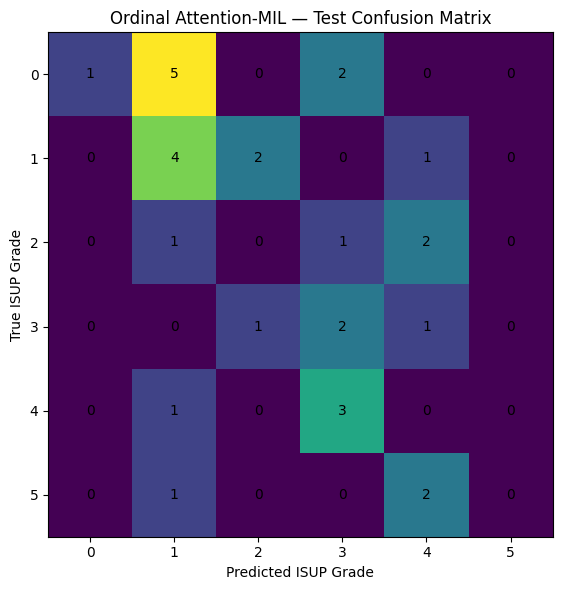

In [86]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt

# Predictions from the previously evaluated Ordinal Attention-MIL model
# Replace these two variables if your ordinal predictions were stored
# under different names.

ordinal_test_true = np.array(test_true_ordinal)
ordinal_test_preds = np.array(test_preds_ordinal)

cm = confusion_matrix(
    ordinal_test_true,
    ordinal_test_preds,
    labels=[0, 1, 2, 3, 4, 5]
)

print("Ordinal Attention-MIL — Test Confusion Matrix")
print()
print(cm)

print("\nClassification Report")
print(
    classification_report(
        ordinal_test_true,
        ordinal_test_preds,
        labels=[0, 1, 2, 3, 4, 5],
        target_names=[
            "ISUP 0",
            "ISUP 1",
            "ISUP 2",
            "ISUP 3",
            "ISUP 4",
            "ISUP 5"
        ],
        zero_division=0
    )
)

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title("Ordinal Attention-MIL — Test Confusion Matrix")
plt.xlabel("Predicted ISUP Grade")
plt.ylabel("True ISUP Grade")

plt.xticks(
    range(6),
    ["0", "1", "2", "3", "4", "5"]
)

plt.yticks(
    range(6),
    ["0", "1", "2", "3", "4", "5"]
)

for i in range(6):
    for j in range(6):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [87]:
import os
import shutil

results_dir = "/content/pathoscope_05/final_results"
os.makedirs(results_dir, exist_ok=True)

# Save model comparison
comparison_csv = os.path.join(
    results_dir,
    "model_comparison.csv"
)
comparison_results.to_csv(
    comparison_csv,
    index=False
)

# Save confusion matrix
cm_csv = os.path.join(
    results_dir,
    "ordinal_attention_mil_confusion_matrix.csv"
)
pd.DataFrame(
    cm,
    index=[f"True_ISUP_{i}" for i in range(6)],
    columns=[f"Pred_ISUP_{i}" for i in range(6)]
).to_csv(cm_csv)

# Save classification report
report_dict = classification_report(
    ordinal_test_true,
    ordinal_test_preds,
    labels=[0, 1, 2, 3, 4, 5],
    target_names=[
        "ISUP 0",
        "ISUP 1",
        "ISUP 2",
        "ISUP 3",
        "ISUP 4",
        "ISUP 5"
    ],
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

report_csv = os.path.join(
    results_dir,
    "ordinal_attention_mil_classification_report.csv"
)
report_df.to_csv(report_csv)

# Save confusion matrix figure
confusion_fig = os.path.join(
    results_dir,
    "ordinal_attention_mil_confusion_matrix.png"
)

plt.figure(figsize=(7, 6))
plt.imshow(cm)

plt.title("Ordinal Attention-MIL — Test Confusion Matrix")
plt.xlabel("Predicted ISUP Grade")
plt.ylabel("True ISUP Grade")

plt.xticks(range(6), range(6))
plt.yticks(range(6), range(6))

for i in range(6):
    for j in range(6):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.savefig(
    confusion_fig,
    dpi=200,
    bbox_inches="tight"
)
plt.close()

print("Saved local results:")
print(comparison_csv)
print(cm_csv)
print(report_csv)
print(confusion_fig)

Saved local results:
/content/pathoscope_05/final_results/model_comparison.csv
/content/pathoscope_05/final_results/ordinal_attention_mil_confusion_matrix.csv
/content/pathoscope_05/final_results/ordinal_attention_mil_classification_report.csv
/content/pathoscope_05/final_results/ordinal_attention_mil_confusion_matrix.png


In [88]:
import os
import shutil

drive_results_dir = (
    "/content/drive/MyDrive/PathoScope/data/"
    "notebook_05_results"
)

os.makedirs(drive_results_dir, exist_ok=True)

# Files to back up
files_to_backup = [
    "/content/pathoscope_05/combined_attention_mil.pth",
    "/content/pathoscope_05/final_results/model_comparison.csv",
    "/content/pathoscope_05/final_results/"
    "ordinal_attention_mil_confusion_matrix.csv",
    "/content/pathoscope_05/final_results/"
    "ordinal_attention_mil_classification_report.csv",
    "/content/pathoscope_05/final_results/"
    "ordinal_attention_mil_confusion_matrix.png"
]

for src in files_to_backup:

    if os.path.exists(src):

        dst = os.path.join(
            drive_results_dir,
            os.path.basename(src)
        )

        shutil.copy2(src, dst)

        print("Backed up:", os.path.basename(src))

    else:
        print("MISSING:", src)

print("\nDrive results directory:")
print(drive_results_dir)

print("\nFiles currently in Drive:")
for filename in sorted(os.listdir(drive_results_dir)):
    filepath = os.path.join(
        drive_results_dir,
        filename
    )
    size_mb = os.path.getsize(filepath) / (1024 ** 2)
    print(f"{filename}  ({size_mb:.2f} MB)")

Backed up: combined_attention_mil.pth
Backed up: model_comparison.csv
Backed up: ordinal_attention_mil_confusion_matrix.csv
Backed up: ordinal_attention_mil_classification_report.csv
Backed up: ordinal_attention_mil_confusion_matrix.png

Drive results directory:
/content/drive/MyDrive/PathoScope/data/notebook_05_results

Files currently in Drive:
combined_attention_mil.pth  (1.51 MB)
model_comparison.csv  (0.00 MB)
ordinal_attention_mil_classification_report.csv  (0.00 MB)
ordinal_attention_mil_confusion_matrix.csv  (0.00 MB)
ordinal_attention_mil_confusion_matrix.png  (0.05 MB)
